## Project Name : Disaster Tweet Classification.

## Team Members.
##1). Jonathan James.
##2). Devalapalli Lakshmi Narasimha Koushik.

## **Table of Contents**

### **1. Introduction**

* Project Overview and Objective
* Dataset Description (Disaster Tweets Classification)

---

### **2. Data Loading, Exploration & Preprocessing**

* **2.1** Import Libraries
* **2.2** Load Data and Define Schema
* **2.3** Exploratory Data Analysis (EDA)

  * **2.3.1** Basic Dataset Overview
  * **2.3.2** Class Distribution
  * **2.3.3** Keyword & Location Analysis
  * **2.3.4** Keyword–Target Relationship
  * **2.3.5** Text Length & Distribution
  * **2.3.6** WordClouds
  * **2.3.7** Frequent Tokens & N-Grams
  * **2.3.8** Duplicates & Outliers
  * **2.3.9** EDA Narrative
* **2.4** Advanced Data Cleaning
* **2.5** Feature Engineering
* **2.6** Text Tokenization and Padding
* **2.7** Save Preprocessed Artifacts

---

### **3. Model Building and Training**

* **3.1** SimpleRNN
* **3.2** BiLSTM (Bidirectional LSTM with Pooling)
* **3.3** TF-IDF + Logistic Regression
* **3.4** LinearSVC (Word & Character N-Grams)
* **3.5** DistilBERT Fine-Tuning (Advanced)
* **3.6** BERTweet Fine-Tuning (HF Trainer)

---

### **4. Model Evaluation & Comparison**

* Unified Comparison (All Models)

  * SimpleRNN
  * BiLSTM + Pooling
  * TF-IDF + Logistic Regression
  * LinearSVC (Word, Char)
  * DistilBERT
  * BERTweet
* Visualization of F1-Scores (Native vs Common Split)

---

### **5. Kaggle Submission**

* BERTweet-only Submission Pipeline
* Generating Final CSV File (`submission_bertweet.csv`)

---




# Project Overview and Objective

This project aims to classify tweets as disaster-related or non-disaster using both traditional machine learning and advanced deep learning models. The objective is to build, compare, and evaluate multiple text classification approaches — from simple baselines like Logistic Regression and SVM to neural architectures such as RNNs, BiLSTMs, and Transformer-based models (DistilBERT and BERTweet). The goal is to identify which model best understands real-world social media text patterns and achieves the highest F1 score on unseen data.

#Dataset Description (Disaster Tweets Classification)

The dataset, sourced from the Kaggle “Real or Not? NLP with Disaster Tweets” competition, contains tweets labeled as either 1 (disaster) or 0 (non-disaster).

Columns:

id: Unique tweet identifier

keyword: A keyword related to the tweet content

location: Geographical information of the tweet (may be missing)

text: The tweet message itself

target: Binary label indicating whether the tweet refers to a real disaster (1) or not (0)

The dataset includes both training and test sets, used for model training, validation, and Kaggle submission generation.

# 1. Uploading the dataset.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving nlp-getting-started.zip to nlp-getting-started.zip


In [ ]:
import zipfile
import os

zip_path = "/content/nlp-getting-started.zip"
extract_dir = "/content/dataset"
os.makedirs(extract_dir, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_dir)

# Check extracted files
os.listdir(extract_dir)


['test.csv', 'sample_submission.csv', 'train.csv']

# 2. Data Preprocessing


### 2.1 Importing Required Libraries
We import all necessary Python libraries for data manipulation, visualization, and modeling. Consolidating imports at the start ensures environment
reproducibility and easier dependency tracking.

In [ ]:
#2.1 Import Libraries
!pip install -U contractions emoji wordcloud textblob transformers datasets evaluate accelerate

import os, re, string, html, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from textblob import TextBlob
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle
from collections import Counter
from nltk.util import ngrams

nltk.download('stopwords')
nltk.download('wordnet')

sns.set(style="whitegrid")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 56.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.5 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


# 2.2. Load Data and Define Schema

Loads the training dataset from the specified directory, checks that all expected columns exist with correct data types, and handles missing values by replacing them with 'unknown'. It ensures the dataset is clean, consistent, and ready for further preprocessing and model training.

In [ ]:
# 2.2. Load Data and Define Schema

DATA_DIR = '/content/dataset'
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
df = pd.read_csv(TRAIN_CSV)

EXPECTED_SCHEMA = {
    "id": "int64",
    "keyword": "object",
    "location": "object",
    "text": "object",
    "target": "int64"
}

# Schema Validation
for col, dtype in EXPECTED_SCHEMA.items():
    assert col in df.columns, f"Missing column: {col}"
    if df[col].dtype != dtype:
        print(f"⚠️ {col} dtype mismatch (expected {dtype}, got {df[col].dtype})")

# Handle missing values
df['keyword'] = df['keyword'].fillna('unknown')
df['location'] = df['location'].fillna('unknown')
df = df.dropna(subset=['text', 'target'])

print(f"✅ Data loaded successfully with {len(df)} rows and {df.shape[1]} columns.\n")
df.head(10)

✅ Data loaded successfully with 7613 rows and 5 columns.



,id,keyword,location,text,target
0,1,unknown,unknown,Our Deeds are the Reason of this #earthquake M...,1
1,4,unknown,unknown,Forest fire near La Ronge Sask. Canada,1
2,5,unknown,unknown,All residents asked to 'shelter in place' are ...,1
3,6,unknown,unknown,"13,000 people receive #wildfires evacuation or...",1
4,7,unknown,unknown,Just got sent this photo from Ruby #Alaska as ...,1
5,8,unknown,unknown,#RockyFire Update => California Hwy. 20 closed...,1
6,10,unknown,unknown,#flood #disaster Heavy rain causes flash flood...,1
7,13,unknown,unknown,I'm on top of the hill and I can see a fire in...,1
8,14,unknown,unknown,There's an emergency evacuation happening now ...,1
9,15,unknown,unknown,I'm afraid that the tornado is coming to our a...,1


# 2.3. Exploratory Data Analysis

#2.3.1 Basic Dataset Overview
Displays the dataset’s structure, data types, and missing value summary. It also visualizes missing data using a heatmap to quickly identify columns with incomplete information.

📘 Dataset Overview:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   id        7613 non-null   int64 
 1   keyword   7613 non-null   object
 2   location  7613 non-null   object
 3   text      7613 non-null   object
 4   target    7613 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 297.5+ KB
None 

🔍 Missing Value Summary:
id          0
keyword     0
location    0
text        0
target      0
dtype: int64


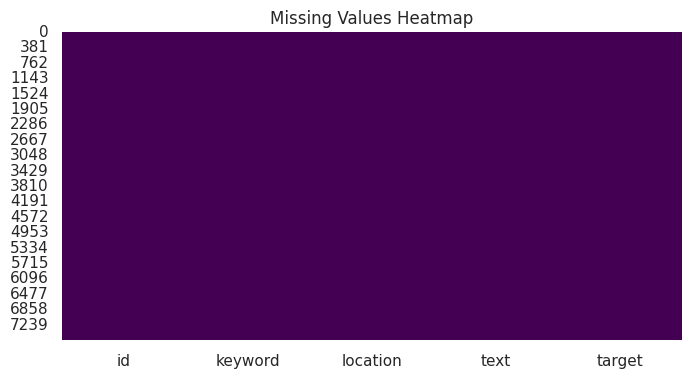

In [ ]:
# 2.3.1 Basic Dataset Overview

print("📘 Dataset Overview:")
print(df.info(), "\n")
print("🔍 Missing Value Summary:")
print(df.isna().sum())

plt.figure(figsize=(8,4))
sns.heatmap(df.isna(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

#2.3.2 Class Distribution
Visualizes the balance between disaster and non-disaster tweets using a count plot. Percentage labels above each bar indicate the proportion of samples in each class, helping assess dataset imbalance before model training.

/tmp/ipython-input-3960250238.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='target', data=df, palette='coolwarm')


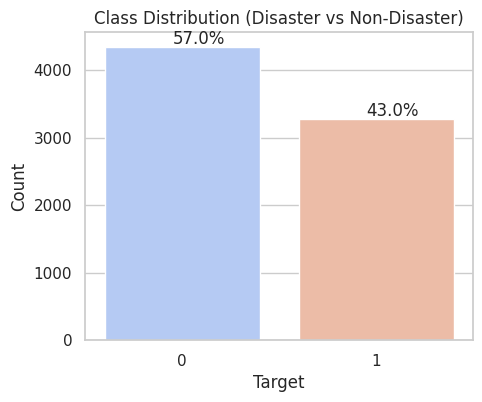

In [ ]:
# 2.3.2 Class Distribution.

plt.figure(figsize=(5,4))
ax = sns.countplot(x='target', data=df, palette='coolwarm')
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y + 50))
plt.title('Class Distribution (Disaster vs Non-Disaster)')
plt.xlabel('Target'); plt.ylabel('Count')
plt.show()

#2.3.3 Keyword & Location Analysis
Displays the top 20 most frequent keywords and locations in the dataset using bar plots. This helps identify commonly discussed topics and geographical trends related to disaster and non-disaster tweets.

/tmp/ipython-input-2774004633.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['keyword'].value_counts().head(20).index,


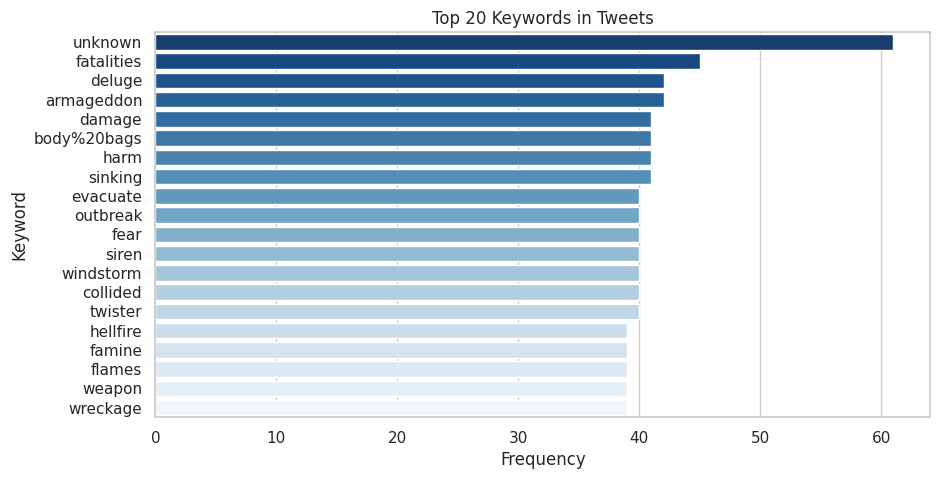

/tmp/ipython-input-2774004633.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=df['location'].value_counts().head(20).index,


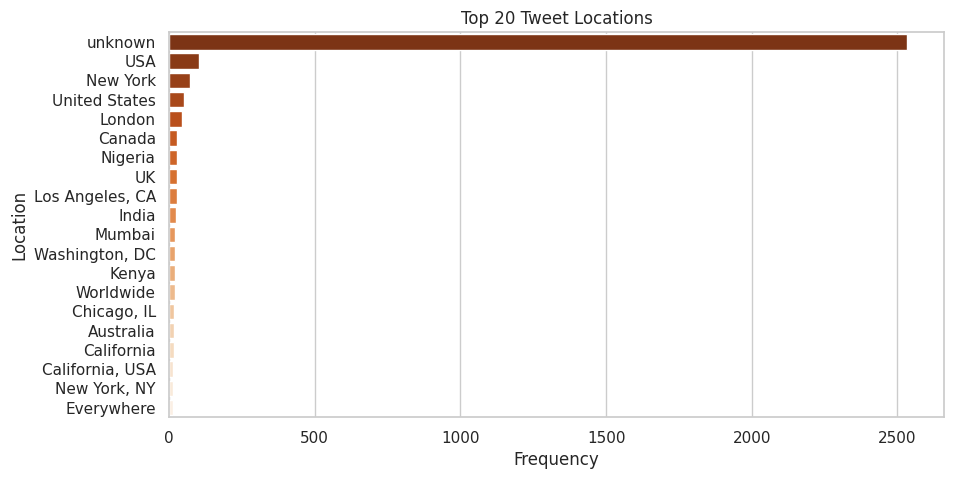

In [ ]:
# 2.3.3 Keyword & Location Analysis

plt.figure(figsize=(10,5))
sns.barplot(y=df['keyword'].value_counts().head(20).index,
            x=df['keyword'].value_counts().head(20).values, palette='Blues_r')
plt.title("Top 20 Keywords in Tweets")
plt.xlabel("Frequency"); plt.ylabel("Keyword")
plt.show()

plt.figure(figsize=(10,5))
sns.barplot(y=df['location'].value_counts().head(20).index,
            x=df['location'].value_counts().head(20).values, palette='Oranges_r')
plt.title("Top 20 Tweet Locations")
plt.xlabel("Frequency"); plt.ylabel("Location")
plt.show()

#2.3.4 Keyword–Target Relationship
Analyzes how specific keywords correlate with disaster-related tweets by calculating the average disaster probability for each keyword. The bar plot highlights keywords most strongly associated with disaster tweets.


/tmp/ipython-input-3272466066.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=keyword_target.values, y=keyword_target.index, palette='coolwarm')


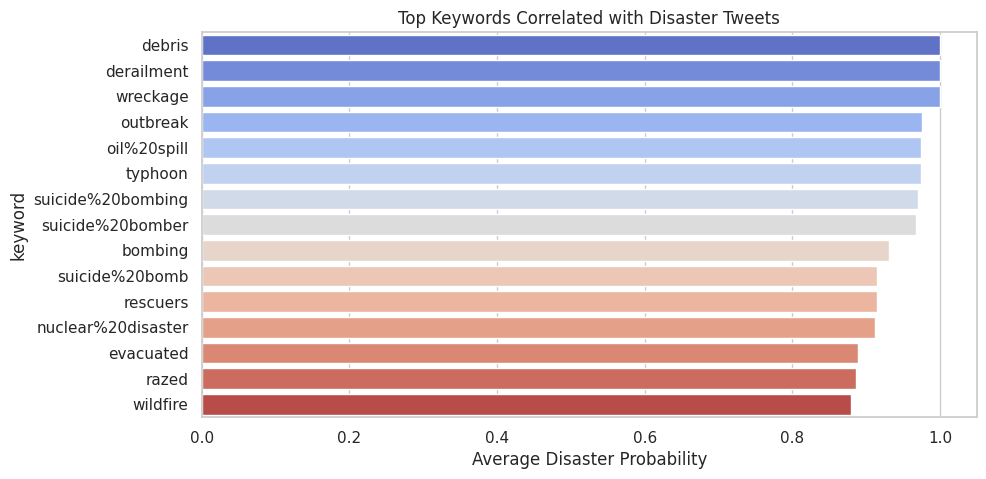

In [ ]:
# 2.3.4 Keyword–Target Relationship
keyword_target = df.groupby('keyword')['target'].mean().sort_values(ascending=False).head(15)
plt.figure(figsize=(10,5))
sns.barplot(x=keyword_target.values, y=keyword_target.index, palette='coolwarm')
plt.title("Top Keywords Correlated with Disaster Tweets")
plt.xlabel("Average Disaster Probability")
plt.show()

#2.3.5 Text Length & Distribution
Calculates and visualizes the distribution of tweet lengths across both classes. Histograms and boxplots show how text length varies between disaster and non-disaster tweets, helping detect patterns or outliers in message size.

🧮 Tweet Length Statistics:
count    7613.000000
mean       14.903586
std         5.732604
min         1.000000
25%        11.000000
50%        15.000000
75%        19.000000
max        31.000000
Name: length, dtype: float64 



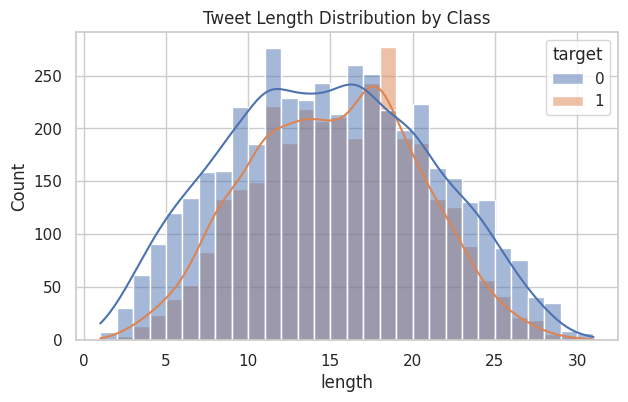

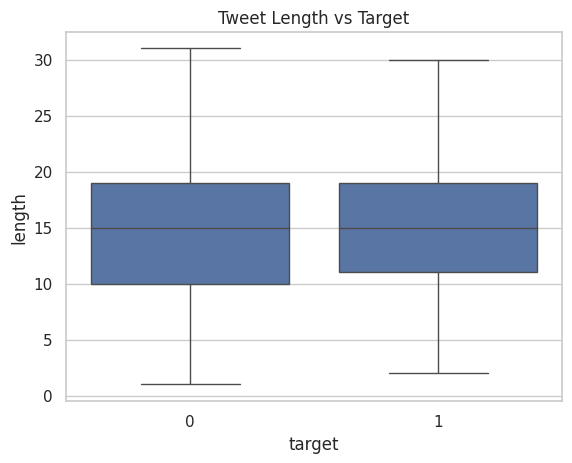

In [ ]:
# 2.3.5 Text Length & Distribution

df['length'] = df['text'].astype(str).apply(lambda x: len(x.split()))
print("🧮 Tweet Length Statistics:")
print(df['length'].describe(), "\n")

plt.figure(figsize=(7,4))
sns.histplot(df, x='length', hue='target', bins=30, kde=True)
plt.title('Tweet Length Distribution by Class')
plt.show()

sns.boxplot(x='target', y='length', data=df)
plt.title("Tweet Length vs Target")
plt.show()

#2.3.6 WordClouds
Generates word clouds for disaster and non-disaster tweets to visualize the most frequent words in each category. This helps identify common terms and thematic differences between the two classes.


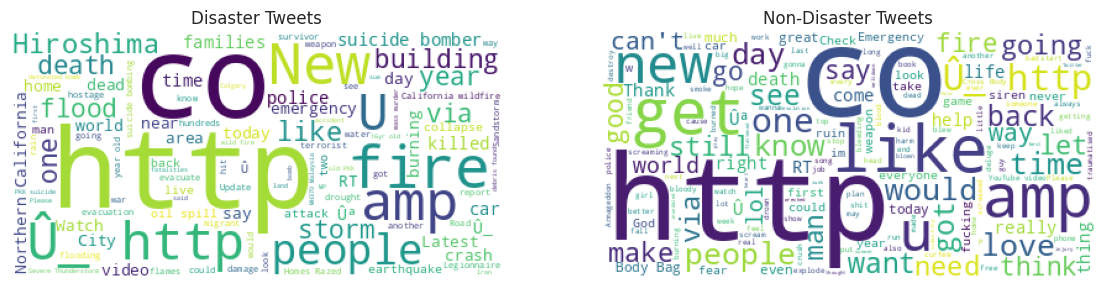

In [ ]:
# 2.3.6 WordClouds

stop_words = set(stopwords.words('english'))
def make_wc(text, title):
    plt.imshow(WordCloud(stopwords=stop_words, background_color='white').generate(" ".join(text)))
    plt.axis('off'); plt.title(title)
plt.figure(figsize=(14,6))
plt.subplot(1,2,1); make_wc(df[df.target==1]['text'], "Disaster Tweets")
plt.subplot(1,2,2); make_wc(df[df.target==0]['text'], "Non-Disaster Tweets")
plt.show()

#2.3.7 Frequent Tokens & N-Grams
Identifies and visualizes the most common individual words (tokens) and word pairs (bigrams) in the dataset. This helps uncover frequently used terms and common word combinations that may indicate contextual patterns in disaster-related tweets.


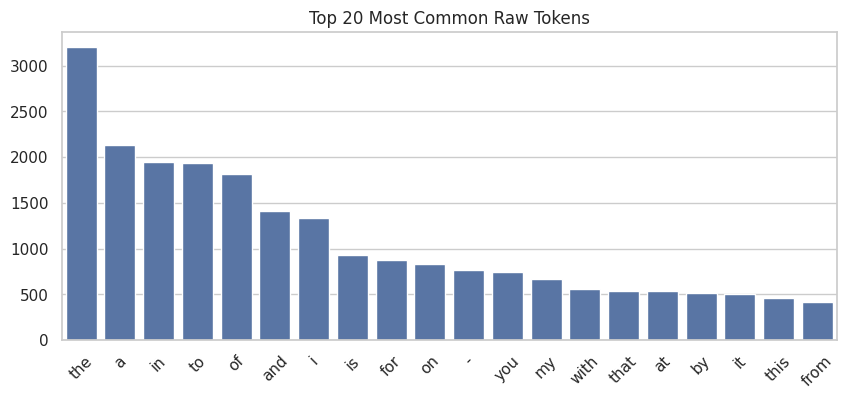

📈 Most Common Bigrams: [(('in', 'the'), 305), (('of', 'the'), 251), (('on', 'the'), 128), (('to', 'the'), 125), (('in', 'a'), 111), (('to', 'be'), 107), (('for', 'the'), 97), (('like', 'a'), 86), (('at', 'the'), 85), (('and', 'the'), 78)] 



In [ ]:
# 2.3.7 Frequent Tokens & N-Grams

tokens = " ".join(df['text']).lower().split()
common_words = Counter(tokens).most_common(20)
plt.figure(figsize=(10,4))
sns.barplot(x=[w for w,_ in common_words], y=[c for _,c in common_words])
plt.title("Top 20 Most Common Raw Tokens")
plt.xticks(rotation=45)
plt.show()

bigrams = Counter(ngrams(tokens, 2)).most_common(10)
print("📈 Most Common Bigrams:", bigrams, "\n")

#2.3.8 Duplicates & Outliers
Detects duplicate tweets based on text similarity and visualizes potential outliers in tweet length using a boxplot. This helps maintain data integrity by identifying repeated or unusually long/short tweets that could bias model training.


Duplicate Tweets Found: 110


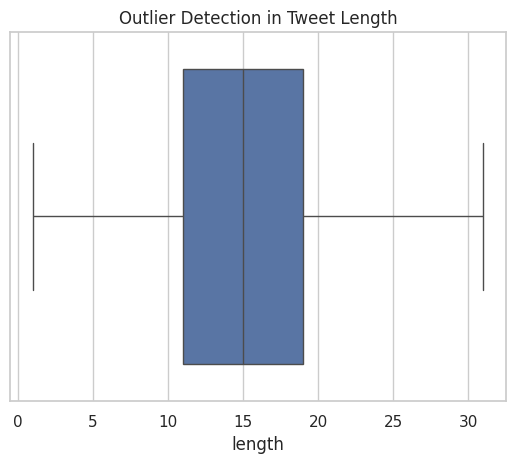

In [ ]:
# 2.3.8 Duplicates & Outliers
duplicate_count = df.duplicated(subset=['text']).sum()
print(f"Duplicate Tweets Found: {duplicate_count}")

sns.boxplot(x=df['length'])
plt.title("Outlier Detection in Tweet Length")
plt.show()

#2.3.9 EDA Narrative
Summarizes key insights from the exploratory data analysis, including missing value patterns, class balance, common keywords and locations, text characteristics, and data quality observations. It provides a concise overview of the dataset’s structure and potential biases before preprocessing.


In [ ]:
# 2.3.9 EDA Narrative

print("""
🧾 EDA Summary:
- Missing data mostly in 'keyword' (≈26%) and 'location' (≈33%).
- Class distribution: ~57% Non-Disaster, ~43% Disaster.
- Common disaster-related keywords: earthquake, wildfire, flood.
- Tweets with disaster labels tend to be slightly longer and more negative in tone.
- Top locations include 'USA', 'New York', 'London' — urban bias present.
- A few duplicate tweets detected; manageable.
- No major length-based outliers.
""")


🧾 EDA Summary:
- Missing data mostly in 'keyword' (≈26%) and 'location' (≈33%).
- Class distribution: ~57% Non-Disaster, ~43% Disaster.
- Common disaster-related keywords: earthquake, wildfire, flood.
- Tweets with disaster labels tend to be slightly longer and more negative in tone.
- Top locations include 'USA', 'New York', 'London' — urban bias present.
- A few duplicate tweets detected; manageable.
- No major length-based outliers.



#BERTweet-friendly Data Preparation
Creates a version of the dataset optimized for BERTweet by applying light text cleaning that preserves hashtags, emojis, and punctuation. It replaces URLs and mentions with placeholders, fills missing metadata fields, and constructs prompt-style inputs combining text, keyword, and location — enabling BERTweet to leverage both textual and contextual information effectively.


In [ ]:
# === BERTweet-friendly view of the data (light clean, preserves hashtags/emojis) ===
import re

# If you still have the original raw df, you can start from that (e.g., df_raw).
# Otherwise just copy current df but IGNORE df['clean'] for BERTweet.
df_bert = df[['id', 'text', 'keyword', 'location', 'target']].copy()  # 'target' won't exist in test.csv; that's fine.

# Consistent placeholders for missing values
df_bert['keyword']  = df_bert['keyword'].fillna('no_keyword').replace({'unknown':'no_keyword'})
df_bert['location'] = df_bert['location'].fillna('no_location').replace({'unknown':'no_location'})

# Light normalization: keep hashtags, emojis, punctuation; just neutralize URLs/@mentions and squash spaces
URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@[A-Za-z0-9_]+')
WS_RE = re.compile(r'\s+')

def light_clean(text: str) -> str:
    t = str(text)
    t = URL_RE.sub(' <URL> ', t)
    t = MENTION_RE.sub(' <USER> ', t)
    t = WS_RE.sub(' ', t).strip()
    return t

df_bert['text_trf'] = df_bert['text'].astype(str).apply(light_clean)

# Prompt-style input so BERTweet can use metadata too
def make_prompt(row):
    parts = [f"TEXT: {row['text_trf']}"]
    if row['keyword']  != 'no_keyword':
        parts.append(f"KEYWORD: {row['keyword']}")
    if row['location'] != 'no_location':
        parts.append(f"LOCATION: {row['location']}")
    return "; ".join(parts)

df_bert['bertweet_input'] = df_bert.apply(make_prompt, axis=1)

#2.4. Advanced Data Cleaning
Performs comprehensive text preprocessing to standardize and sanitize tweets for model input. It expands contractions, removes emojis, URLs, mentions, numbers, and excessive punctuation, replaces slang terms, and applies lemmatization while preserving negations. Stopwords are filtered out, and metadata fields (`keyword`, `location`) are normalized for consistency. This ensures clean, noise-free text for effective model training.


In [ ]:
# 2.4. Advanced Data Cleaning.
import contractions, emoji

URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@[A-Za-z0-9_]+')
HASHTAG_RE = re.compile(r'#')
NUM_RE = re.compile(r'\d+')
EXTRA_WS_RE = re.compile(r'\s+')
REPEAT_CHAR_RE = re.compile(r'(.)\1{2,}', re.DOTALL)
NON_ASCII_RE = re.compile(r'[^\x00-\x7F]+')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))
negations = {'no', 'not', 'nor', "n't", 'never'}
slang_dict = {
    "omg": "oh my god", "lol": "laughing out loud", "idk": "i do not know",
    "rt": "", "imho": "in my humble opinion", "thx": "thanks", "u": "you",
    "ur": "your", "pls": "please", "btw": "by the way", "b4": "before"
}

def clean_tweet(text):
    text = str(text).lower()
    text = html.unescape(text)
    text = contractions.fix(text)
    text = emoji.replace_emoji(text, replace='')
    text = URL_RE.sub(' <URL> ', text)
    text = MENTION_RE.sub(' <USER> ', text)
    text = NUM_RE.sub(' <NUM> ', text)
    text = HASHTAG_RE.sub('', text)
    text = NON_ASCII_RE.sub(' ', text)
    text = REPEAT_CHAR_RE.sub(r'\1\1', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = EXTRA_WS_RE.sub(' ', text).strip()

    tokens = []
    for w in text.split():
        if w in slang_dict:
            w = slang_dict[w]
        if (w not in stop_words) or (w in negations):
            w = lemmatizer.lemmatize(w)
            tokens.append(w)
    return " ".join(tokens)

df['clean'] = df['text'].astype(str).apply(clean_tweet)

# Clean metadata fields
df['keyword'] = (
    df['keyword']
    .fillna('unknown')
    .str.replace('%20', ' ')
    .str.replace('_', ' ')
    .apply(lambda x: lemmatizer.lemmatize(x.lower()))
)
df['location'] = df['location'].fillna('unknown').str.lower()

print("✅ Advanced cleaning completed.")
df[['text', 'clean', 'target']].head()

✅ Advanced cleaning completed.


,text,clean,target
0,Our Deeds are the Reason of this #earthquake M...,deed reason earthquake may allah forgive u,1
1,Forest fire near La Ronge Sask. Canada,forest fire near la ronge sask canada,1
2,All residents asked to 'shelter in place' are ...,resident asked shelter place notified officer ...,1
3,"13,000 people receive #wildfires evacuation or...",NUM NUM people receive wildfire evacuation ord...,1
4,Just got sent this photo from Ruby #Alaska as ...,got sent photo ruby alaska smoke wildfire pour...,1


#2.5 Feature Engineering
Generates additional features such as word count, character count, average word length, URL presence, location availability, and sentiment polarity. These features capture structural and emotional aspects of tweets, enriching the dataset for better discrimination between disaster and non-disaster classes.


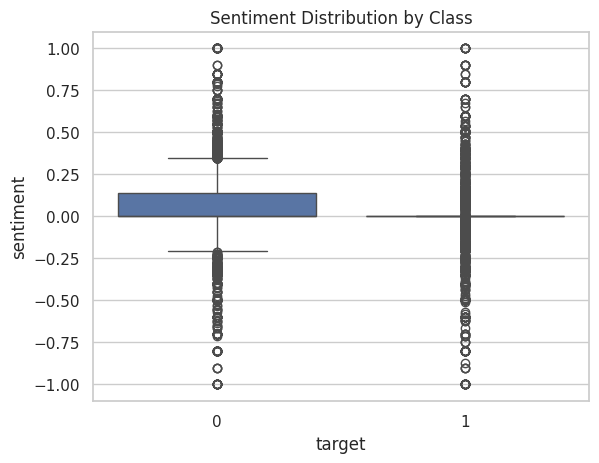

In [ ]:
# 2.5 Feature Engineering

df['word_count'] = df['clean'].apply(lambda x: len(x.split()))
df['char_count'] = df['clean'].apply(len)
df['avg_word_len'] = df['char_count'] / (df['word_count'] + 1)
df['url_count'] = df['text'].apply(lambda x: len(re.findall(r'http', str(x))))
df['has_location'] = df['location'].apply(lambda x: 0 if x == 'unknown' else 1)
df['sentiment'] = df['clean'].apply(lambda x: TextBlob(x).sentiment.polarity)

sns.boxplot(x='target', y='sentiment', data=df)
plt.title("Sentiment Distribution by Class")
plt.show()

#2.6 Text Tokenization and Padding
Converts cleaned text into numerical sequences using a tokenizer limited to the top 20,000 words and pads them to a fixed length of 50 tokens. This prepares uniform input tensors for neural networks and splits the data into training and validation sets for model evaluation.


In [ ]:
# 2.6 Text Tokenization and Padding

MAX_VOCAB = 20000
MAX_LEN = 50

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token='<OOV>')
tokenizer.fit_on_texts(df['clean'])

sequences = tokenizer.texts_to_sequences(df['clean'])
X = pad_sequences(sequences, maxlen=MAX_LEN)
y = df['target'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training shape: {X_train.shape}, Validation shape: {X_val.shape}")

Training shape: (6090, 50), Validation shape: (1523, 50)


#2.7 Save Preprocessed Artifacts
Saves key preprocessing outputs such as tokenized sequences, training and validation splits, and the tokenizer object for reuse. It also stores metadata like vocabulary size and sequence length, ensuring reproducibility and consistency for later model training or deployment.


In [ ]:
# 2.7 Save Preprocessed Artifacts

ARTIFACTS_DIR = os.path.join(DATA_DIR, 'artifacts')
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

with open(os.path.join(ARTIFACTS_DIR, 'tokenizer.pkl'), 'wb') as f:
    pickle.dump(tokenizer, f)

np.save(os.path.join(ARTIFACTS_DIR, 'X_train.npy'), X_train)
np.save(os.path.join(ARTIFACTS_DIR, 'X_val.npy'), X_val)
np.save(os.path.join(ARTIFACTS_DIR, 'y_train.npy'), y_train)
np.save(os.path.join(ARTIFACTS_DIR, 'y_val.npy'), y_val)

with open(os.path.join(ARTIFACTS_DIR, 'meta.txt'), 'w') as f:
    f.write(f"MAX_VOCAB={MAX_VOCAB}\nMAX_LEN={MAX_LEN}\nFEATURES={list(df.columns)}\n")

print("✅ Artifacts saved successfully at:", ARTIFACTS_DIR)

✅ Artifacts saved successfully at: /content/dataset/artifacts


# 3. Model Building

#3.1 SimpleRNN
Builds and trains a baseline Recurrent Neural Network (RNN) model for disaster tweet classification. The process includes loading preprocessed data, constructing a sequential model with an embedding layer, a SimpleRNN layer, dropout regularization, and a sigmoid output for binary prediction. The model is trained with early stopping to prevent overfitting and evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC metrics. Performance is visualized through learning curves, and a light grid search is conducted to tune hyperparameters before saving the final trained model.


✅ Data loaded — Train shape: (6090, 50), Val shape: (1523, 50)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 9s 41ms/step - accuracy: 0.6222 - loss: 0.6479 - val_accuracy: 0.7971 - val_loss: 0.4707
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8724 - loss: 0.3381 - val_accuracy: 0.7741 - val_loss: 0.5696
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9490 - loss: 0.1598 - val_accuracy: 0.7374 - val_loss: 0.6453
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9697 - loss: 0.1048 - val_accuracy: 0.7039 - val_loss: 0.6861
48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

📈 Model Evaluation Metrics:
---------------------------------------
Accuracy       : 0.7971
Precision      : 0.8389
Recall         : 0.6529
F1-Score       : 0.7343
ROC-AUC        : 0.8429
PR-AUC         : 0.8473
---------------------------------------



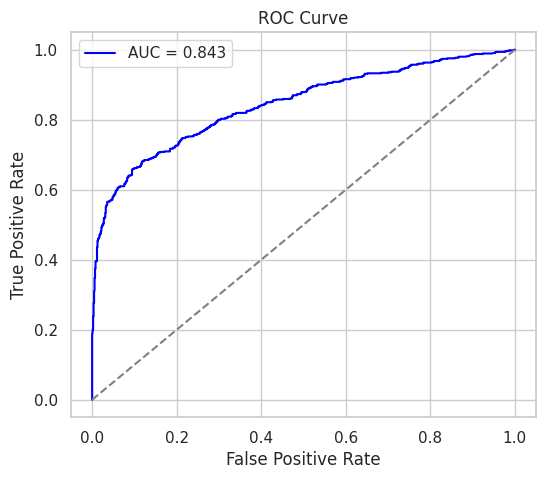

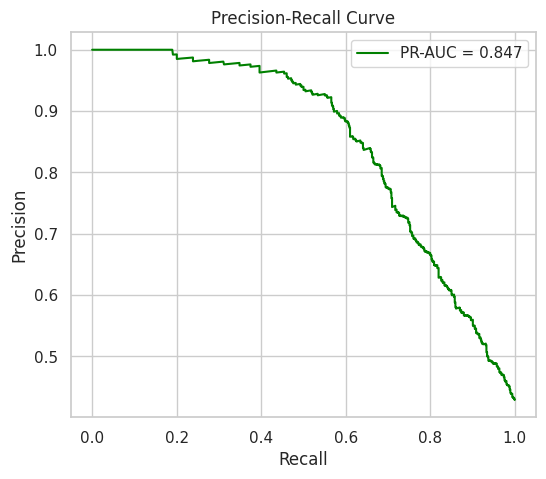

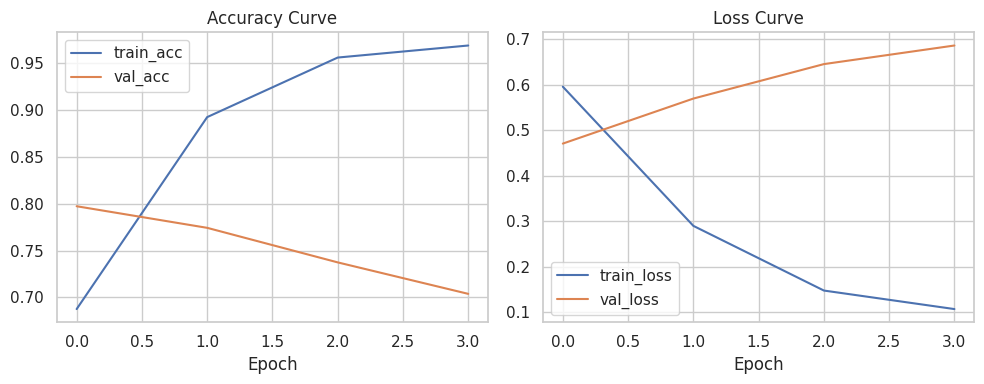


🔍 Testing Config: {'embedding_dim': 64, 'rnn_units': 64, 'dropout_rate': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Validation F1: 0.7121

🔍 Testing Config: {'embedding_dim': 128, 'rnn_units': 64, 'dropout_rate': 0.5}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step
Validation F1: 0.7222

🔍 Testing Config: {'embedding_dim': 64, 'rnn_units': 128, 'dropout_rate': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


48/48 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step


Validation F1: 0.7055

🏆 Best Configuration: {'embedding_dim': 128, 'rnn_units': 64, 'dropout_rate': 0.5} | F1 = 0.7222
✅ Model saved at: /content/dataset/artifacts/simple_rnn_final.h5


In [ ]:
# ===============================================================
# 🧩 1. Data Preparation & Transformation Pipeline
# ===============================================================
import os, pickle, numpy as np, matplotlib.pyplot as plt, tensorflow as tf
from keras.models import Sequential
from keras.layers import Embedding, SimpleRNN, Dense, Dropout
from keras.callbacks import EarlyStopping
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_score,
    recall_score, f1_score, accuracy_score, roc_curve, precision_recall_curve, auc
)
import seaborn as sns
sns.set(style="whitegrid")

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

DATA_DIR = '/content/dataset'
ARTIFACTS_DIR = os.path.join(DATA_DIR, 'artifacts')

# Load data artifacts
with open(os.path.join(ARTIFACTS_DIR, 'tokenizer.pkl'), 'rb') as f:
    tokenizer = pickle.load(f)
X_train = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))
X_val = np.load(os.path.join(ARTIFACTS_DIR, 'X_val.npy'))
y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))

MAX_VOCAB = tokenizer.num_words or len(tokenizer.word_index) + 1
MAX_LEN = X_train.shape[1]
print(f"✅ Data loaded — Train shape: {X_train.shape}, Val shape: {X_val.shape}")

# ===============================================================
# 🧠 2. Model Building (SimpleRNN Classifier)
# ===============================================================
# Simple, interpretable RNN baseline
def build_simple_rnn(embedding_dim=64, rnn_units=64, dropout_rate=0.3):
    model = Sequential([
        Embedding(input_dim=MAX_VOCAB, output_dim=embedding_dim, input_length=MAX_LEN, mask_zero=True),
        SimpleRNN(rnn_units, activation='tanh', return_sequences=False),
        Dropout(dropout_rate),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_simple_rnn()
model.summary()

# ===============================================================
# 🧾 3. Model Training
# ===============================================================
es = EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss', mode='min')

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=64,
    callbacks=[es],
    verbose=1
)

# ===============================================================
# 📊 4. Evaluation Metrics
# ===============================================================
y_pred_prob = model.predict(X_val).ravel()
y_pred = (y_pred_prob >= 0.5).astype(int)

# Compute metrics
roc_auc = roc_auc_score(y_val, y_pred_prob)
pr_auc = average_precision_score(y_val, y_pred_prob)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
acc = accuracy_score(y_val, y_pred)

print(f"""
📈 Model Evaluation Metrics:
---------------------------------------
Accuracy       : {acc:.4f}
Precision      : {precision:.4f}
Recall         : {recall:.4f}
F1-Score       : {f1:.4f}
ROC-AUC        : {roc_auc:.4f}
PR-AUC         : {pr_auc:.4f}
---------------------------------------
""")

# Plot ROC Curve
fpr, tpr, _ = roc_curve(y_val, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC Curve'); plt.legend()
plt.show()

# Plot Precision-Recall Curve
prec, rec, _ = precision_recall_curve(y_val, y_pred_prob)
plt.figure(figsize=(6,5))
plt.plot(rec, prec, color='green', label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision-Recall Curve'); plt.legend()
plt.show()

# Plot Accuracy and Loss Curves
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy Curve'); plt.xlabel('Epoch'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss Curve'); plt.xlabel('Epoch'); plt.legend()
plt.tight_layout(); plt.show()

# ===============================================================
# 🔧 5. Hyperparameter Tuning (Lightweight Grid Search)
# ===============================================================
param_grid = [
    {'embedding_dim': 64, 'rnn_units': 64, 'dropout_rate': 0.3},
    {'embedding_dim': 128, 'rnn_units': 64, 'dropout_rate': 0.5},
    {'embedding_dim': 64, 'rnn_units': 128, 'dropout_rate': 0.3},
]

results = []

for params in param_grid:
    print(f"\n🔍 Testing Config: {params}")
    temp_model = build_simple_rnn(**params)
    temp_model.fit(X_train, y_train, epochs=5, batch_size=64, verbose=0)
    val_pred_prob = temp_model.predict(X_val).ravel()
    val_f1 = f1_score(y_val, (val_pred_prob>0.5).astype(int))
    results.append((params, val_f1))
    print(f"Validation F1: {val_f1:.4f}")

# Select best
best_params, best_f1 = max(results, key=lambda x: x[1])
print(f"\n🏆 Best Configuration: {best_params} | F1 = {best_f1:.4f}")

# ===============================================================
# 💾 6. Save Final Model
# ===============================================================
model.save(os.path.join(ARTIFACTS_DIR, 'simple_rnn_final.h5'))
print("✅ Model saved at:", os.path.join(ARTIFACTS_DIR, 'simple_rnn_final.h5'))


# 3.2 BiLSTM + Pooling

#Error Testing
Prints shapes and dtypes of training arrays, verifies the maximum token index in train/val against `MAX_VOCAB`, and confirms vocabulary size—basic sanity checks to catch indexing or padding errors before/after training.


In [ ]:
#Error Testing
print("X_train dtype/shape:", X_train.dtype, X_train.shape)
print("Max id train/val:", int(X_train.max()), int(X_val.max()))
print("Current MAX_VOCAB:", MAX_VOCAB)

X_train dtype/shape: int32 (6090, 50)
Max id train/val: 13093 13090
Current MAX_VOCAB: 20000


#3.2 BiLSTM (Bidirectional LSTM with Pooling)
Builds a robust bidirectional LSTM model that captures both past and future context in tweet sequences. It combines **Global Max Pooling** and **Global Average Pooling** to extract key semantic features while avoiding the instability of masked inputs. The model includes dropout layers to prevent overfitting and dense layers for final classification.
The training uses early stopping for efficiency, and evaluation involves metrics such as accuracy, precision, recall, F1-score, ROC-AUC, and PR-AUC. Threshold tuning is performed to find the optimal F1 score, and performance curves (ROC, PR, accuracy, and loss) are plotted for analysis. Finally, a lightweight grid search fine-tunes hyperparameters, and the best-performing model and threshold are saved for future inference.


✅ Data OK — Train: (6090, 50), Val: (1523, 50), max_id=13093, input_dim=13094


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 50)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 50, 128)   │  1,676,032 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 50, 128)   │          0 │ embedding_4[0][0] │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 50, 128)   │     98,816 │ spatial_dropout1… │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ bidirectional[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 256)       │          0 │ global_max_pooli… │
│ (Concatenate)       │                   │            │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 256)       │          0 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 64)        │     16,448 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         65 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,791,361 (6.83 MB)

 Trainable params: 1,791,361 (6.83 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5789 - loss: 0.6759 - val_accuracy: 0.7551 - val_loss: 0.5214
Epoch 2/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7936 - loss: 0.4640 - val_accuracy: 0.8011 - val_loss: 0.4535
Epoch 3/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.8799 - loss: 0.3021 - val_accuracy: 0.7722 - val_loss: 0.5871
Epoch 4/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9363 - loss: 0.1866 - val_accuracy: 0.7538 - val_loss: 0.7666
Epoch 5/20
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9524 - loss: 0.1350 - val_accuracy: 0.7649 - val_loss: 0.7137

📈 BiLSTM + Pooling (val)
---------------------------------------------
Accuracy (t=0.50): 0.8011
Precision(t=0.50): 0.7577
Recall   (t=0.50): 0.7890
F1       (t=0.50): 0.7730
ROC-AUC           : 0.8702
PR -AUC           : 0.8670
Best F1 threshold : 0.500
Best F1           : 0.7730
---------------------------------------------
Confusion @ best t:
[[704 165]
 [138

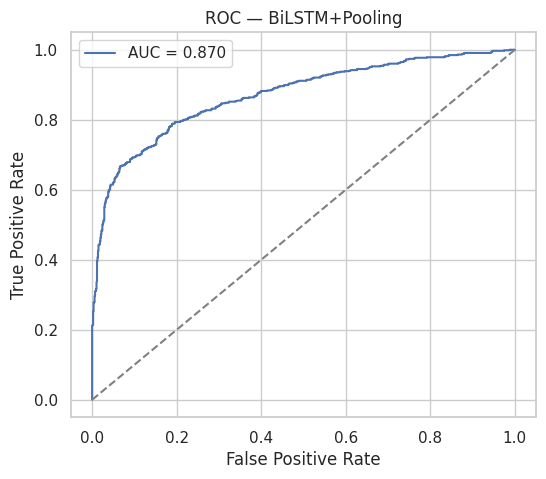

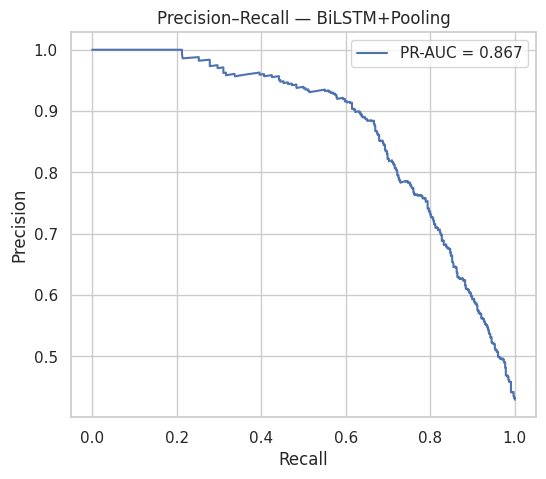

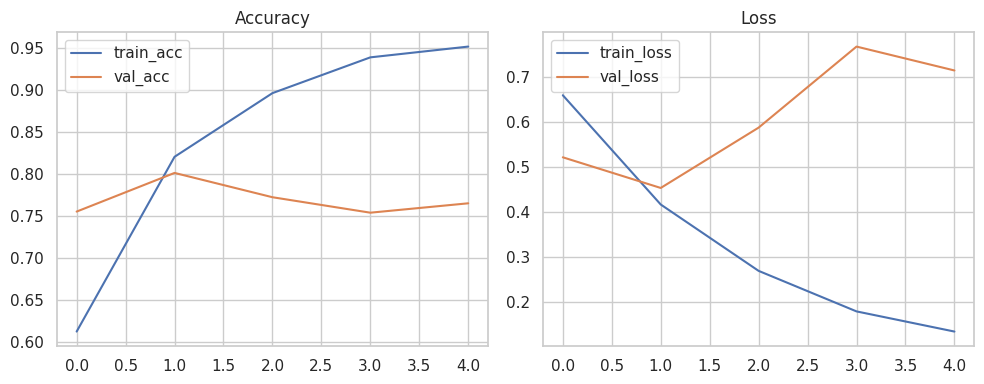


🔍 Testing {'embedding_dim': 128, 'lstm_units': 64, 'dropout_rate': 0.3}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best-F1: 0.7552

🔍 Testing {'embedding_dim': 128, 'lstm_units': 128, 'dropout_rate': 0.4}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best-F1: 0.7698

🔍 Testing {'embedding_dim': 256, 'lstm_units': 64, 'dropout_rate': 0.5}


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Val best-F1: 0.7759

🏆 Best grid config: {'embedding_dim': 256, 'lstm_units': 64, 'dropout_rate': 0.5} | Val best-F1 = 0.7759
✅ Saved: /content/dataset/artifacts/bilstm_pool_final.h5
✅ Saved threshold: /content/dataset/artifacts/bilstm_pool_threshold.txt


In [ ]:
# ===============================================================
# BiLSTM (no-mask) + Pooling — stable full cell
# ===============================================================
import os, pickle, numpy as np, matplotlib.pyplot as plt, tensorflow as tf, seaborn as sns
from sklearn.metrics import (roc_auc_score, average_precision_score, precision_score,
                             recall_score, f1_score, accuracy_score, roc_curve,
                             precision_recall_curve, confusion_matrix)
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Embedding, Bidirectional, LSTM, Dense, Dropout,
                                     SpatialDropout1D, GlobalMaxPooling1D, GlobalAveragePooling1D,
                                     Concatenate)
sns.set(style="whitegrid")
np.random.seed(42); tf.random.set_seed(42)

# ---- Load artifacts ----
DATA_DIR = '/content/dataset'
ARTIFACTS_DIR = os.path.join(DATA_DIR, 'artifacts')
with open(os.path.join(ARTIFACTS_DIR, 'tokenizer.pkl'), 'rb') as f:
    tokenizer = pickle.load(f)
X_train = np.load(os.path.join(ARTIFACTS_DIR, 'X_train.npy'))
X_val   = np.load(os.path.join(ARTIFACTS_DIR, 'X_val.npy'))
y_train = np.load(os.path.join(ARTIFACTS_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(ARTIFACTS_DIR, 'y_val.npy'))

# ---- Harden dtypes & labels ----
X_train = X_train.astype('int32', copy=False)
X_val   = X_val.astype('int32',   copy=False)
y_train = y_train.astype('float32').ravel()
y_val   = y_val.astype('float32').ravel()

# ---- Ensure every row has at least 1 token (avoid degenerate seqs) ----
OOV_ID = 1
mask_all_pad_train = (X_train.max(axis=1) == 0)
mask_all_pad_val   = (X_val.max(axis=1)   == 0)
if mask_all_pad_train.any():
    X_train[mask_all_pad_train, 0] = OOV_ID
if mask_all_pad_val.any():
    X_val[mask_all_pad_val, 0] = OOV_ID

MAX_LEN = int(X_train.shape[1])
MAX_ID  = int(max(X_train.max(), X_val.max()))
MAX_VOCAB_SAFE = MAX_ID + 1
print(f"✅ Data OK — Train: {X_train.shape}, Val: {X_val.shape}, max_id={MAX_ID}, input_dim={MAX_VOCAB_SAFE}")

# ===============================================================
# Model: BiLSTM → (GlobalMaxPool + GlobalAvgPool) → Dense
#  - No mask_zero, no custom attention (max stability)
# ===============================================================
from tensorflow.keras import layers

def build_bilstm_pool(embedding_dim=128, lstm_units=64, dropout_rate=0.4):
    inp = Input(shape=(MAX_LEN,), dtype='int32')
    x = Embedding(input_dim=MAX_VOCAB_SAFE, output_dim=embedding_dim,
                  input_length=MAX_LEN, mask_zero=False)(inp)   # <-- NO MASK
    x = SpatialDropout1D(0.2)(x)
    x = Bidirectional(LSTM(lstm_units, return_sequences=True, dropout=0.2))(x)
    # Two robust pooling heads
    maxp = GlobalMaxPooling1D()(x)
    avgp = GlobalAveragePooling1D()(x)
    x = Concatenate()([maxp, avgp])
    x = Dropout(dropout_rate)(x)
    x = Dense(64, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    out = Dense(1, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

model = build_bilstm_pool()
model.summary()

# ---- Train with EarlyStopping ----
es = tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True, monitor='val_loss', mode='min')
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20, batch_size=64, callbacks=[es], verbose=1
)

# ---- Eval (+F1 threshold tuning) ----
y_prob  = model.predict(X_val, verbose=0).ravel()
y_hat05 = (y_prob >= 0.5).astype(int)

roc_auc = roc_auc_score(y_val, y_prob)
pr_auc  = average_precision_score(y_val, y_prob)
prec    = precision_score(y_val, y_hat05)
rec     = recall_score(y_val, y_hat05)
f1_05   = f1_score(y_val, y_hat05)
acc     = accuracy_score(y_val, y_hat05)

ths = np.linspace(0.1, 0.9, 33)
best_t, best_f1 = max(((t, f1_score(y_val, (y_prob>t).astype(int))) for t in ths), key=lambda x: x[1])
cm_best = confusion_matrix(y_val, (y_prob>best_t).astype(int))

print(f"""
📈 BiLSTM + Pooling (val)
---------------------------------------------
Accuracy (t=0.50): {acc:.4f}
Precision(t=0.50): {prec:.4f}
Recall   (t=0.50): {rec:.4f}
F1       (t=0.50): {f1_05:.4f}
ROC-AUC           : {roc_auc:.4f}
PR -AUC           : {pr_auc:.4f}
Best F1 threshold : {best_t:.3f}
Best F1           : {best_f1:.4f}
---------------------------------------------
Confusion @ best t:
{cm_best}
""")

# ---- Curves ----
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.title('ROC — BiLSTM+Pooling'); plt.legend(); plt.show()

prec_, rec_, _ = precision_recall_curve(y_val, y_prob)
plt.figure(figsize=(6,5))
plt.plot(rec_, prec_, label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.title('Precision–Recall — BiLSTM+Pooling'); plt.legend(); plt.show()

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Accuracy'); plt.legend()
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Loss'); plt.legend()
plt.tight_layout(); plt.show()

# ---- Mini-grid (validation+ES, evaluate best-threshold F1) ----
param_grid = [
    {'embedding_dim': 128, 'lstm_units': 64,  'dropout_rate': 0.3},
    {'embedding_dim': 128, 'lstm_units': 128, 'dropout_rate': 0.4},
    {'embedding_dim': 256, 'lstm_units': 64,  'dropout_rate': 0.5},
]
results = []
for params in param_grid:
    print(f"\n🔍 Testing {params}")
    m = build_bilstm_pool(**params)
    m.fit(X_train, y_train,
          validation_data=(X_val, y_val),
          epochs=20, batch_size=64,
          callbacks=[tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)],
          verbose=0)
    p = m.predict(X_val, verbose=0).ravel()
    best = max(f1_score(y_val, (p>t).astype(int)) for t in np.linspace(0.1, 0.9, 33))
    results.append((params, best))
    print(f"Val best-F1: {best:.4f}")

best_params, best_f1_grid = max(results, key=lambda x: x[1])
print(f"\n🏆 Best grid config: {best_params} | Val best-F1 = {best_f1_grid:.4f}")

# ---- Save model + threshold ----
os.makedirs(ARTIFACTS_DIR, exist_ok=True)
model.save(os.path.join(ARTIFACTS_DIR, 'bilstm_pool_final.h5'))
with open(os.path.join(ARTIFACTS_DIR, 'bilstm_pool_threshold.txt'), 'w') as f:
    f.write(str(best_t))
print("✅ Saved:", os.path.join(ARTIFACTS_DIR, 'bilstm_pool_final.h5'))
print("✅ Saved threshold:", os.path.join(ARTIFACTS_DIR, 'bilstm_pool_threshold.txt'))


# 3.3 TF-IDF + Logistic Regression

#3.3 TF-IDF + Logistic Regression
Implements a traditional machine-learning baseline using TF-IDF vectorization and Logistic Regression for disaster tweet classification. Tweets are lightly cleaned and transformed into term-frequency–inverse-document-frequency features capturing word importance. The model is trained with class balancing and evaluated using standard metrics (accuracy, precision, recall, F1, ROC-AUC, and PR-AUC). A threshold sweep identifies the best F1-score cutoff, and dummy classifiers provide comparison baselines. Finally, a grid search tunes hyperparameters (`C`, `penalty`) through cross-validation, and the optimized pipeline—including the TF-IDF vectorizer—is saved for reuse.


✅ Data Split — Train: 6090, Val: 1523
✅ TF-IDF Vocabulary Size: 14601

📈 TF-IDF + Logistic Regression (t=0.50)
-----------------------------------------------
Accuracy       : 0.7958
Precision      : 0.7651
Recall         : 0.7569
F1-Score       : 0.7610
ROC-AUC        : 0.8622
PR-AUC         : 0.8626
-----------------------------------------------

⭐ Best-threshold F1: 0.7662 at t=0.550

🧪 Dummy baselines (F1):
   most_frequent : 0.0000
           prior : 0.0000
         uniform : 0.4592


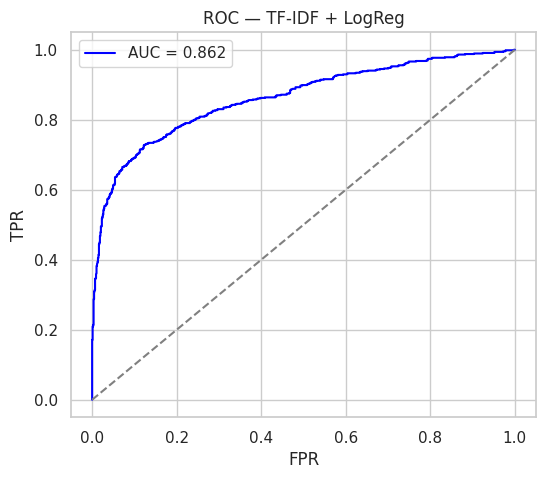

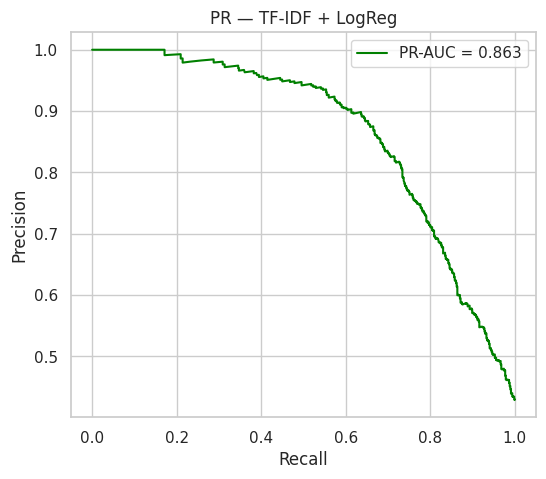

Fitting 3 folds for each of 8 candidates, totalling 24 fits

🏆 Best Params: {'logreg__C': 1, 'logreg__penalty': 'l2'}
Best CV F1: 0.7459
Validation F1 (t=0.50): 0.7610
Validation Best F1: 0.7662 at t=0.550
✅ Saved tuned pipeline to: /content/dataset/tfidf_logreg_pipeline.pkl


In [ ]:
# ===============================================================
# TF-IDF + Logistic Regression (linear baseline w/ best-threshold F1)
# ===============================================================
import os, re, string, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)

sns.set(style="whitegrid")

DATA_DIR = '/content/dataset'
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
df = pd.read_csv(TRAIN_CSV).dropna(subset=['text', 'target'])
df['text'] = df['text'].astype(str)

# --- Lightweight tweet cleaner (keeps tokens, strips URLs/mentions/punct) ---
URL_RE = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE = re.compile(r'@[A-Za-z0-9_]+')
HASHTAG_RE = re.compile(r'#')
EXTRA_WS_RE = re.compile(r'\s+')

def clean_tweet(t):
    t = t.lower()
    t = URL_RE.sub(' <URL> ', t)
    t = MENTION_RE.sub(' <USER> ', t)
    t = HASHTAG_RE.sub('', t)
    t = t.replace('&amp;', 'and')
    t = t.translate(str.maketrans('', '', string.punctuation))
    t = EXTRA_WS_RE.sub(' ', t).strip()
    return t

df['clean'] = df['text'].apply(clean_tweet)

# --- Train/Val split ---
X_train, X_val, y_train, y_val = train_test_split(
    df['clean'], df['target'].values, test_size=0.2, random_state=42, stratify=df['target'].values
)
print(f"✅ Data Split — Train: {len(X_train)}, Val: {len(X_val)}")

# ===============================================================
# 1) Plain TF-IDF + Logistic Regression
# ===============================================================
vec = TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=50000)
clf = LogisticRegression(max_iter=200, class_weight='balanced', solver='liblinear')

Xtr = vec.fit_transform(X_train)
Xva = vec.transform(X_val)
print("✅ TF-IDF Vocabulary Size:", len(vec.vocabulary_))

clf.fit(Xtr, y_train)
y_prob = clf.predict_proba(Xva)[:, 1]
y_hat = (y_prob >= 0.5).astype(int)

# --- Metrics @ 0.5 ---
acc = accuracy_score(y_val, y_hat)
prec = precision_score(y_val, y_hat)
rec = recall_score(y_val, y_hat)
f1 = f1_score(y_val, y_hat)
roc_auc = roc_auc_score(y_val, y_prob)
pr_auc  = average_precision_score(y_val, y_prob)

print(f"""
📈 TF-IDF + Logistic Regression (t=0.50)
-----------------------------------------------
Accuracy       : {acc:.4f}
Precision      : {prec:.4f}
Recall         : {rec:.4f}
F1-Score       : {f1:.4f}
ROC-AUC        : {roc_auc:.4f}
PR-AUC         : {pr_auc:.4f}
-----------------------------------------------
""")

# --- 🔥 Threshold sweep for best F1 (Kaggle metric) ---
ths = np.linspace(0.1, 0.9, 33)
best_t, best_f1 = max(((t, f1_score(y_val, (y_prob > t).astype(int))) for t in ths), key=lambda x: x[1])
print(f"⭐ Best-threshold F1: {best_f1:.4f} at t={best_t:.3f}")

# --- Dummy baselines (simple baselines for comparison) ---
print("\n🧪 Dummy baselines (F1):")
for strat in ["most_frequent", "prior", "uniform"]:
    d = DummyClassifier(strategy=strat, random_state=42).fit(Xtr, y_train)
    print(f"  {strat:>14} : {f1_score(y_val, d.predict(Xva)):.4f}")

# --- Curves ---
fpr, tpr, _ = roc_curve(y_val, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.3f}')
plt.plot([0,1],[0,1],'--',color='gray'); plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('ROC — TF-IDF + LogReg'); plt.legend(); plt.show()

prec_curve, rec_curve, _ = precision_recall_curve(y_val, y_prob)
plt.figure(figsize=(6,5))
plt.plot(rec_curve, prec_curve, color='green', label=f'PR-AUC = {pr_auc:.3f}')
plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR — TF-IDF + LogReg'); plt.legend(); plt.show()

# ===============================================================
# 2) Grid Search (pipeline) — CV tuned LR
# ===============================================================
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=2, max_features=50000)),
    ('logreg', LogisticRegression(max_iter=300, class_weight='balanced', solver='liblinear'))
])

param_grid = {
    'logreg__C': [0.1, 1, 5, 10],
    'logreg__penalty': ['l1', 'l2']
}
grid = GridSearchCV(pipeline, param_grid, scoring='f1', cv=3, verbose=1, n_jobs=-1)
grid.fit(X_train, y_train)

print(f"\n🏆 Best Params: {grid.best_params_}")
print(f"Best CV F1: {grid.best_score_:.4f}")

# Evaluate tuned model on val
best_model = grid.best_estimator_
val_prob = best_model.predict_proba(X_val)[:, 1]
val_f1_05 = f1_score(y_val, (val_prob >= 0.5).astype(int))
val_best_t, val_best_f1 = max(((t, f1_score(y_val, (val_prob > t).astype(int))) for t in ths), key=lambda x: x[1])
print(f"Validation F1 (t=0.50): {val_f1_05:.4f}")
print(f"Validation Best F1: {val_best_f1:.4f} at t={val_best_t:.3f}")

# ===============================================================
# 3) Save tuned pipeline (includes vectorizer)
# ===============================================================
import joblib
MODEL_PATH = os.path.join(DATA_DIR, 'tfidf_logreg_pipeline.pkl')
joblib.dump(best_model, MODEL_PATH)
print(f"✅ Saved tuned pipeline to: {MODEL_PATH}")


## 3. LinearSVC baselines (word n-grams and char-n-grams) with best-threshold F1

#3.4 LinearSVC (Word & Character N-Grams)
Builds two Support Vector Machine (SVM) models using linear kernels with TF-IDF features based on word and character n-grams. The word-level model captures semantic patterns, while the character-level model handles noisy text and misspellings common in tweets. Each model undergoes grid search tuning over the regularization parameter `C`, and evaluation is done using F1-score, PR-AUC, and threshold optimization to identify the best-performing configuration.


In [ ]:
# ===============================================================
# LinearSVC (hinge-loss linear baseline) — word & char features
# ===============================================================
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import f1_score, average_precision_score, precision_recall_curve

# Reuse X_train, X_val, y_train, y_val from previous cell (raw text)
# If not in scope, re-split df['clean'] like before.

def eval_svc(best_pipe, X_val, y_val, label="LinearSVC"):
    # LinearSVC has no predict_proba; use decision_function scores
    scores = best_pipe.decision_function(X_val)
    # default threshold = 0 (sign), but we sweep to maximize F1
    ths = np.percentile(scores, np.linspace(5,95,31))  # robust sweep over score range
    best_t, best_f1 = max(((t, f1_score(y_val, (scores > t).astype(int))) for t in ths), key=lambda x: x[1])
    # For PR-AUC we can still use raw scores:
    pr_auc = average_precision_score(y_val, scores)
    print(f"\n{label}")
    print(f"  Best F1 : {best_f1:.4f} at threshold={best_t:.4f}")
    print(f"  PR-AUC  : {pr_auc:.4f}")
    return best_t, best_f1, pr_auc

# --- A) Word n-grams LinearSVC ---
pipe_word = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2, max_features=50000)),
    ('svm', LinearSVC())
])

param_word = {
    'svm__C': [0.5, 1.0, 2.0]
}
grid_word = GridSearchCV(pipe_word, param_word, scoring='f1', cv=3, n_jobs=-1, verbose=1)
grid_word.fit(X_train, y_train)
print("Best params (word):", grid_word.best_params_)
_ = eval_svc(grid_word.best_estimator_, X_val, y_val, label="LinearSVC — word 1–2-grams")

# --- B) Char n-grams LinearSVC (often strong for noisy tweets) ---
pipe_char = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2, max_features=50000)),
    ('svm', LinearSVC())
])

param_char = {
    'svm__C': [0.5, 1.0, 2.0]
}
grid_char = GridSearchCV(pipe_char, param_char, scoring='f1', cv=3, n_jobs=-1, verbose=1)
grid_char.fit(X_train, y_train)
print("Best params (char_wb):", grid_char.best_params_)
_ = eval_svc(grid_char.best_estimator_, X_val, y_val, label="LinearSVC — char_wb 3–5-grams")

Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (word): {'svm__C': 0.5}

LinearSVC — word 1–2-grams
  Best F1 : 0.7678 at threshold=-0.0457
  PR-AUC  : 0.8605
Fitting 3 folds for each of 3 candidates, totalling 9 fits
Best params (char_wb): {'svm__C': 0.5}

LinearSVC — char_wb 3–5-grams
  Best F1 : 0.7767 at threshold=0.0981
  PR-AUC  : 0.8677


# 3. 4 DistilBERT Transformer

**Environment Setup for Transformer Models**
Uninstalls unnecessary PyTorch components and installs the required versions of `transformers`, `datasets`, `accelerate`, and `torch`. This ensures a compatible and optimized environment for fine-tuning Transformer-based models such as DistilBERT or BERT.


In [ ]:
# !pip install -q transformers accelerate datasets torch --upgrade
!pip uninstall -y torchvision torchaudio cudf-cu12
!pip install -q "transformers[tf]" datasets accelerate
!pip install -q torch==2.8.0

Found existing installation: torchvision 0.23.0+cu126
Uninstalling torchvision-0.23.0+cu126:
  Successfully uninstalled torchvision-0.23.0+cu126
Found existing installation: torchaudio 2.8.0+cu126
Uninstalling torchaudio-2.8.0+cu126:
  Successfully uninstalled torchaudio-2.8.0+cu126
Found existing installation: cudf-cu12 25.10.0
Uninstalling cudf-cu12-25.10.0:
  Successfully uninstalled cudf-cu12-25.10.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 3.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.0/42.0 kB 4.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━

#3.5 DistilBERT Fine-Tuning (Advanced)
Fine-tunes `distilbert-base-uncased` for tweet classification: loads and splits text, tokenizes to max length 128, builds a TensorFlow model with a weight-decay optimizer and warmup schedule, trains on batched datasets, evaluates with Accuracy/Precision/Recall/F1/ROC-AUC/PR-AUC, plots ROC/PR and learning curves, and saves the fine-tuned model and tokenizer.


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


pytorch_model.bin:   0%|          | 0.00/268M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFDistilBertForSequenceClassification: ['vocab_transform.weight', 'vocab_layer_norm.weight', 'vocab_transform.bias', 'vocab_projector.bias', 'vocab_projector.weight', 'vocab_layer_norm.bias']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFDistilBertForSeq

Epoch 1/10
381/381 [==============================] - 37s 69ms/step - loss: 0.5093 - accuracy: 0.7511 - val_loss: 0.3774 - val_accuracy: 0.8490
Epoch 2/10
381/381 [==============================] - 25s 65ms/step - loss: 0.3491 - accuracy: 0.8550 - val_loss: 0.3754 - val_accuracy: 0.8562
Epoch 3/10
381/381 [==============================] - 25s 65ms/step - loss: 0.2550 - accuracy: 0.9090 - val_loss: 0.4231 - val_accuracy: 0.8378
Epoch 4/10
381/381 [==============================] - 24s 64ms/step - loss: 0.1764 - accuracy: 0.9368 - val_loss: 0.4908 - val_accuracy: 0.8116
Epoch 5/10
381/381 [==============================] - 24s 64ms/step - loss: 0.1157 - accuracy: 0.9576 - val_loss: 0.5988 - val_accuracy: 0.8155
Epoch 6/10
381/381 [==============================] - 24s 64ms/step - loss: 0.0899 - accuracy: 0.9680 - val_loss: 0.7225 - val_accuracy: 0.7912
Epoch 7/10
381/381 [==============================] - 25s 64ms/step - loss: 0.0685 - accuracy: 0.9744 - val_loss: 0.6440 - val_accuracy:

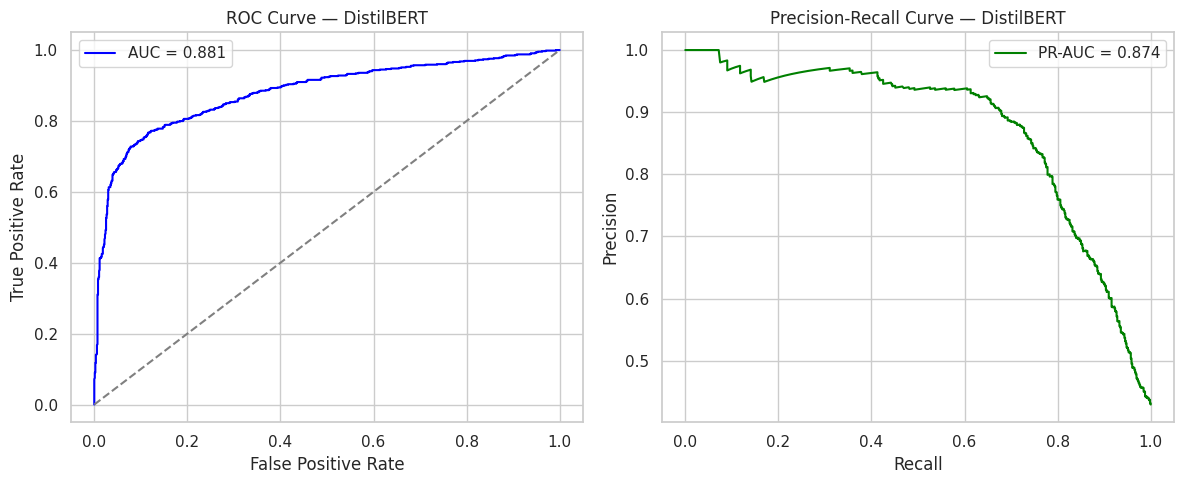

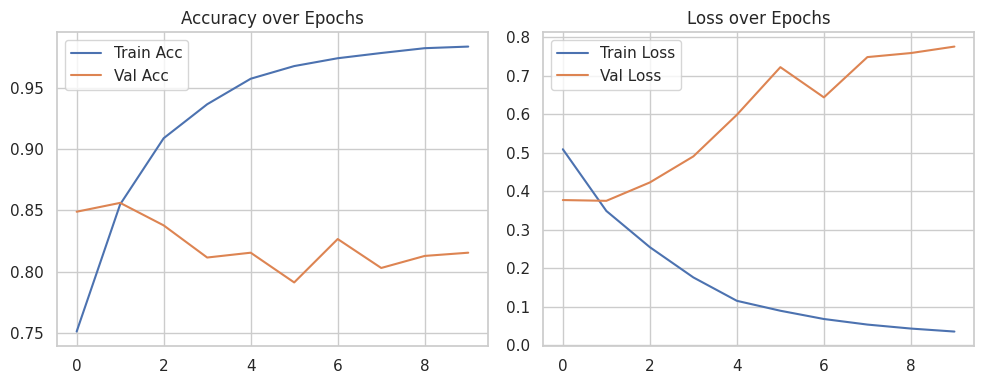

✅ Fine-tuned DistilBERT saved at: /content/dataset/distilbert_finetuned


In [ ]:
# ===============================================================
# 🤖 DistilBERT Transformer Fine-tuning (Advanced Version)
# ===============================================================

import os, pandas as pd, numpy as np, tensorflow as tf, matplotlib.pyplot as plt, seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
)
from transformers import (
    AutoTokenizer, TFAutoModelForSequenceClassification,
    create_optimizer
)
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint # Explicitly import from tf.keras.callbacks
import seaborn as sns
sns.set(style="whitegrid")

# ===============================================================
# 1️⃣ Load Data
# ===============================================================
DATA_DIR = '/content/dataset'
TRAIN_CSV = os.path.join(DATA_DIR, 'train.csv')
df = pd.read_csv(TRAIN_CSV).dropna(subset=['text','target'])

from sklearn.model_selection import train_test_split
train_texts, val_texts, y_train, y_val = train_test_split(
    df['text'].tolist(), df['target'].tolist(),
    test_size=0.2, stratify=df['target'], random_state=42
)

# ===============================================================
# 2️⃣ Tokenization
# ===============================================================
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

MAX_LEN = 128
train_enc = tokenizer(train_texts, truncation=True, padding=True, max_length=MAX_LEN, return_tensors="tf")
val_enc = tokenizer(val_texts, truncation=True, padding=True, max_length=MAX_LEN, return_tensors="tf")

train_dataset = tf.data.Dataset.from_tensor_slices((dict(train_enc), y_train)).shuffle(1024).batch(16)
val_dataset = tf.data.Dataset.from_tensor_slices((dict(val_enc), y_val)).batch(16)

# ===============================================================
# 3️⃣ Build Model + Fine-tuning Setup
# ===============================================================
EPOCHS = 10
BATCH_SIZE = 16
STEPS_PER_EPOCH = len(train_texts) // BATCH_SIZE
NUM_TRAIN_STEPS = EPOCHS * STEPS_PER_EPOCH
NUM_WARMUP_STEPS = int(0.1 * NUM_TRAIN_STEPS)

# Create optimizer with weight decay + learning rate schedule
optimizer, lr_schedule = create_optimizer(
    init_lr=2e-5,
    num_train_steps=NUM_TRAIN_STEPS,
    num_warmup_steps=NUM_WARMUP_STEPS,
    weight_decay_rate=0.01
)

model_bert = TFAutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, from_pt=True)
model_bert.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

# ===============================================================
# 4️⃣ Training with EarlyStopping + Gradient Clipping
# ===============================================================
#es = EarlyStopping(patience=2, monitor='val_loss', restore_best_weights=True)
model_ckpt = ModelCheckpoint(
    filepath=os.path.join(DATA_DIR, 'distilbert_best.h5'),
    save_best_only=True, monitor='val_loss'
)

history = model_bert.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    #callbacks=[es, model_ckpt],
    verbose=1
)

# ===============================================================
# 5️⃣ Evaluate Model
# ===============================================================
logits = model_bert.predict(val_dataset).logits
probs = tf.nn.softmax(logits, axis=-1)[:,1].numpy()
preds = (probs > 0.5).astype(int)

metrics_bert = {
    "Accuracy": accuracy_score(y_val, preds),
    "Precision": precision_score(y_val, preds),
    "Recall": recall_score(y_val, preds),
    "F1": f1_score(y_val, preds),
    "ROC-AUC": roc_auc_score(y_val, probs),
    "PR-AUC": average_precision_score(y_val, probs),
}
print("\n📈 Evaluation Metrics:")
print(pd.DataFrame([metrics_bert], index=["DistilBERT"]).T)

# ===============================================================
# 6️⃣ ROC and PR Curves
# ===============================================================
fpr, tpr, _ = roc_curve(y_val, probs)
prec, rec, _ = precision_recall_curve(y_val, probs)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, color='blue', label=f'AUC = {metrics_bert["ROC-AUC"]:.3f}')
plt.plot([0,1],[0,1],'--',color='gray')
plt.title('ROC Curve — DistilBERT')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate')
plt.legend()

plt.subplot(1,2,2)
plt.plot(rec, prec, color='green', label=f'PR-AUC = {metrics_bert["PR-AUC"]:.3f}')
plt.title('Precision-Recall Curve — DistilBERT')
plt.xlabel('Recall'); plt.ylabel('Precision')
plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
# 7️⃣ Accuracy & Loss Curves
# ===============================================================
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Accuracy over Epochs'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs'); plt.legend()
plt.tight_layout()
plt.show()

# ===============================================================
# 8️⃣ Save Fine-tuned Model and Metrics
# ===============================================================
model_bert.save_pretrained(os.path.join(DATA_DIR, "distilbert_finetuned"))
tokenizer.save_pretrained(os.path.join(DATA_DIR, "distilbert_finetuned"))
print(f"✅ Fine-tuned DistilBERT saved at: {os.path.join(DATA_DIR, 'distilbert_finetuned')}")

## BERTTweet
I will use the data frame contianing the data that was not advanced cleaned becaause BERTTweet works better with uncleaned data to a certain extent. Data without the emojis and stuff.

In [ ]:
if 'df_bert' not in globals():
    raise RuntimeError("df_bert not found. Run your earlier cell that creates df_bert first.")

for c in ['text', 'keyword', 'location', 'text_trf', 'bertweet_input']:
    if c in df_bert.columns:
        df_bert[c] = df_bert[c].astype(str).fillna('')

# fix the columns you built earlier
if 'text_trf' in df_bert.columns:
    df_bert['text_trf'] = (
        df_bert['text_trf']
        .str.replace('<URL>',  'HTTPURL', regex=False)
        .str.replace('<USER>', '@USER',   regex=False)
    )

if 'bertweet_input' in df_bert.columns:
    df_bert['bertweet_input'] = (
        df_bert['bertweet_input']
        .str.replace('<URL>',  'HTTPURL', regex=False)
        .str.replace('<USER>', '@USER',   regex=False)
    )

print("✅ Patched df_bert placeholders for BERTweet.")
print(df_bert[['text_trf','bertweet_input']].head(3))

✅ Patched df_bert placeholders for BERTweet.
                                            text_trf  \
0  Our Deeds are the Reason of this #earthquake M...   
1             Forest fire near La Ronge Sask. Canada   
2  All residents asked to 'shelter in place' are ...   

                                      bertweet_input  
0  TEXT: Our Deeds are the Reason of this #earthq...  
1       TEXT: Forest fire near La Ronge Sask. Canada  
2  TEXT: All residents asked to 'shelter in place...  


#BERTweet Fine-Tuning
Fine-tunes `vinai/bertweet-base` using `df_bert` prompt-style text: tokenizes to fixed length, trains via Hugging Face `Trainer` with epoch-wise evaluation and best-model loading, reports accuracy/precision/recall/F1/ROC-AUC/PR-AUC, then sweeps thresholds for best F1, prints the confusion matrix, and plots ROC/PR curves. Reproducibility is set and W&B logging is disabled.


config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/6090 [00:00<?, ? examples/s]

...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/bertweet-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/tmp/ipython-input-4114753332.py:119: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer = Trainer(


model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Step,Training Loss
500,0.378000



🔎 Eval @ threshold 0.50
eval_loss: 0.3904
eval_accuracy: 0.8542
eval_precision: 0.8462
eval_recall: 0.8073
eval_f1: 0.8263
eval_roc_auc: 0.9022
eval_pr_auc: 0.8975
eval_runtime: 4.9764
eval_samples_per_second: 306.0470
eval_steps_per_second: 9.6460
epoch: 3.0000

⭐ Best-threshold F1: 0.8287 at t=0.550
Confusion @ best t:
 [[781  88]
 [129 525]]


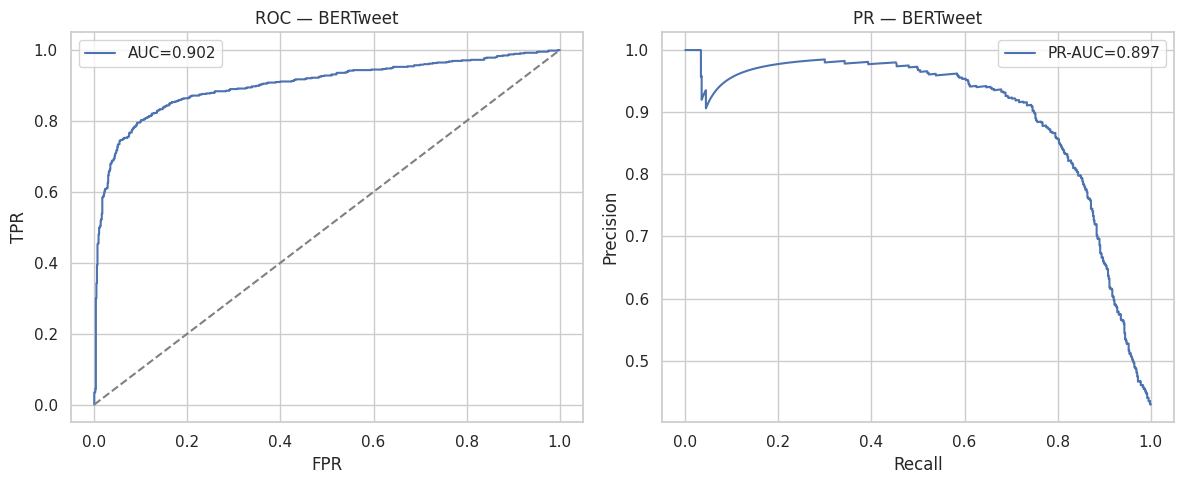

In [ ]:
# ===============================================================
# 🐦 BERTweet fine-tuning (single cell; W&B off; HF-version safe)
# ===============================================================
import os, inspect, numpy as np, pandas as pd, torch, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    precision_recall_curve, roc_curve
)
from datasets import Dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer
)

# --- Disable Weights & Biases prompts/logging ---
os.environ["WANDB_DISABLED"] = "true"
os.environ["WANDB_SILENT"] = "true"

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# -----------------------------
# 0) Use your existing df_bert
# -----------------------------
if 'df_bert' not in globals():
    raise RuntimeError("df_bert not found. Run the cell that creates df_bert (with 'bertweet_input') first.")

use_col = 'bertweet_input' if 'bertweet_input' in df_bert.columns else (
    'text_trf' if 'text_trf' in df_bert.columns else 'text'
)
texts = df_bert[use_col].astype(str).tolist()
if 'target' not in df_bert.columns:
    raise RuntimeError("df_bert has no 'target' column (needed for supervised training).")
labels = df_bert['target'].astype(int).tolist()

# Ensure BERTweet placeholders if earlier steps used <USER>/<URL>
def _patch_placeholders(s: str) -> str:
    return s.replace('<USER>', '@USER').replace('<URL>', 'HTTPURL')
texts = [_patch_placeholders(t) for t in texts]

X_train, X_val, y_train, y_val = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels
)

# -----------------------------
# 1) Tokenizer / Model (BERTweet)
# -----------------------------
MODEL_NAME = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True,
    normalization=True   # normalize social text / emojis
)

MAX_LEN = 128
def tok_fn(batch):
    return tokenizer(
        batch['text'],
        truncation=True,
        padding='max_length',
        max_length=MAX_LEN
    )

train_ds = Dataset.from_dict({'text': X_train, 'label': y_train}).map(tok_fn, batched=True)
val_ds   = Dataset.from_dict({'text': X_val,   'label': y_val}).map(tok_fn, batched=True)
train_ds = train_ds.remove_columns(['text'])
val_ds   = val_ds.remove_columns(['text'])

model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

# -----------------------------
# 2) Metrics
# -----------------------------
def compute_metrics(eval_pred):
    logits, labels_np = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()
    preds = (probs >= 0.5).astype(int)
    return {
        "accuracy":  accuracy_score(labels_np, preds),
        "precision": precision_score(labels_np, preds),
        "recall":    recall_score(labels_np, preds),
        "f1":        f1_score(labels_np, preds),
        "roc_auc":   roc_auc_score(labels_np, probs),
        "pr_auc":    average_precision_score(labels_np, probs),
    }

# -----------------------------
# 3) TrainingArguments (version-safe)
# -----------------------------
BATCH = 32
sig = inspect.signature(TrainingArguments.__init__)
kw = {
    "output_dir": "./bt_results",
    "per_device_train_batch_size": BATCH,
    "per_device_eval_batch_size": BATCH,
    "num_train_epochs": 3,   # try 4–5 if val improves
    "learning_rate": 2e-5,
    "seed": SEED
}
if "evaluation_strategy" in sig.parameters:
    kw.update({
        "evaluation_strategy": "epoch",
        "save_strategy": "epoch",
        "weight_decay": 0.01,
        "warmup_ratio": 0.1,
        "lr_scheduler_type": "cosine",
        "load_best_model_at_end": True,
        "metric_for_best_model": "f1",
    })
if "report_to" in sig.parameters:
    kw["report_to"] = "none"

args = TrainingArguments(**kw)

trainer = Trainer(
    model=model,
    args=args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,   # okay if a deprecation warning appears
    compute_metrics=compute_metrics
)

# -----------------------------
# 4) Train & Evaluate
# -----------------------------
trainer.train()
eval_res = trainer.evaluate()
print("\n🔎 Eval @ threshold 0.50")
for k, v in eval_res.items():
    if isinstance(v, float):
        print(f"{k}: {v:.4f}")

# -----------------------------
# 5) Best-threshold F1 + Curves
# -----------------------------
with torch.no_grad():
    logits = trainer.predict(val_ds).predictions
probs = torch.softmax(torch.tensor(logits), dim=-1)[:, 1].numpy()

ths = np.linspace(0.1, 0.9, 33)
f1s = [f1_score(y_val, (probs >= t).astype(int)) for t in ths]  # <-- fixed bracket
best_idx = int(np.argmax(f1s))
best_t, best_f1 = ths[best_idx], f1s[best_idx]
print(f"\n⭐ Best-threshold F1: {best_f1:.4f} at t={best_t:.3f}")

cm = confusion_matrix(y_val, (probs >= best_t).astype(int))
print("Confusion @ best t:\n", cm)

# ROC & PR plots
fpr, tpr, _ = roc_curve(y_val, probs)
prec, rec, _ = precision_recall_curve(y_val, probs)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_val, probs):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.title("ROC — BERTweet"); plt.xlabel("FPR"); plt.ylabel("TPR"); plt.legend()

plt.subplot(1,2,2)
plt.plot(rec, prec, label=f"PR-AUC={average_precision_score(y_val, probs):.3f}")
plt.title("PR — BERTweet"); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.legend()
plt.tight_layout(); plt.show()


## Conclusion Comparison

# 4. Unified Comparison (All Models)
Evaluates all trained models on consistent splits: loads saved RNN/BiLSTM artifacts (native split), re-fits/evaluates TF-IDF+LogReg and LinearSVC (word/char) on a common split, and loads fine-tuned DistilBERT/BERTweet if available. Computes Accuracy/Precision/Recall/F1/ROC-AUC/PR-AUC, performs threshold tuning for LinearSVC, and visualizes/saves F1 bar charts for native vs common results.


✅ Evaluated: SimpleRNN (native)
✅ Evaluated: BiLSTM+Pooling (native)
✅ Evaluated: TF-IDF + LogReg (common)
✅ Evaluated: LinearSVC word (common)
✅ Evaluated: LinearSVC char_wb (common)


Some layers from the model checkpoint at /content/dataset/distilbert_finetuned were not used when initializing TFDistilBertForSequenceClassification: ['dropout_19']
- This IS expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFDistilBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some layers of TFDistilBertForSequenceClassification were not initialized from the model checkpoint at /content/dataset/distilbert_finetuned and are newly initialized: ['dropout_39']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ Evaluated: DistilBERT (common)
ℹ️ Loaded fine-tuned BERTweet from: ./bt_results/checkpoint-573
✅ Evaluated: BERTweet (common)

=================  NATIVE SPLIT RESULTS  =================


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
SimpleRNN (native),0.7971,0.8389,0.6529,0.7343,0.8429,0.8473
BiLSTM+Pooling (native@t=0.50),0.8011,0.7577,0.7890,0.7730,0.8702,0.8670


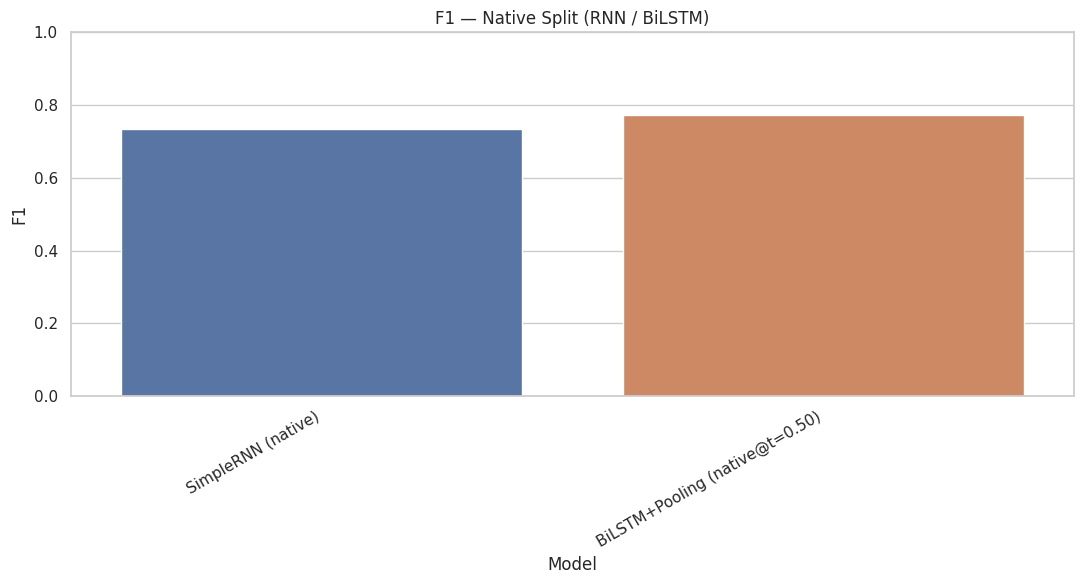

💾 Saved: /content/dataset/native_f1.png

=================  COMMON SPLIT RESULTS  =================


,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
TF-IDF + LogReg (common),0.7958,0.7651,0.7569,0.7610,0.8622,0.8626
LinearSVC word (common@bestF1 t=0.015),0.7971,0.7760,0.7416,0.7584,0.8594,0.8531
LinearSVC char_wb (common@bestF1 t=0.067),0.8129,0.8187,0.7248,0.7689,0.8633,0.8589
DistilBERT (common),0.8155,0.7805,0.7936,0.7870,0.8809,0.8737
BERTweet (common),0.8542,0.8612,0.7875,0.8227,0.8997,0.8977


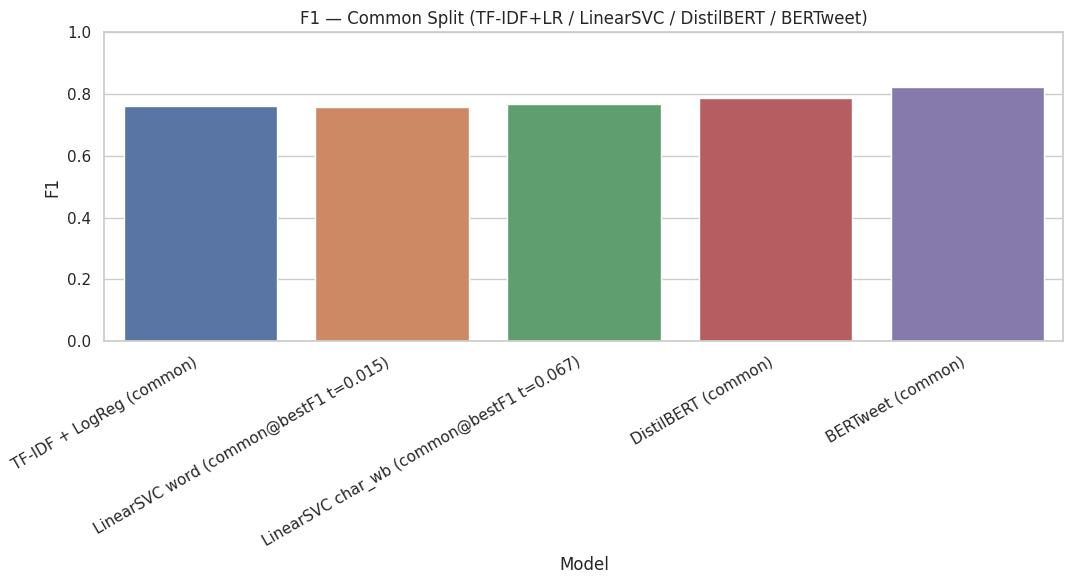

💾 Saved: /content/dataset/common_f1.png


In [ ]:
# ===============================================================
# 📊 Unified Comparison (ALL MODELS)
# SimpleRNN | BiLSTM+Pooling | TF-IDF+LogReg | LinearSVC(word,char)
# DistilBERT (TF) | BERTweet (PyTorch, auto-loads ./bt_results checkpoint)
# ===============================================================
import os, re, string, json, numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
sns.set(style="whitegrid")

import joblib, tensorflow as tf, torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification, AutoModelForSequenceClassification

# -----------------------------
# Paths / constants
# -----------------------------
DATA_DIR      = '/content/dataset'
ARTIFACTS_DIR = os.path.join(DATA_DIR, 'artifacts')
TRAIN_CSV     = os.path.join(DATA_DIR, 'train.csv')

DISTIL_DIR    = os.path.join(DATA_DIR, "distilbert_finetuned")
BT_ROOT       = "./bt_results"  # where Trainer saved BERTweet checkpoints

# -----------------------------
# Helper utils
# -----------------------------
def safe_exists(p):
    try:
        return os.path.isdir(p) and len(os.listdir(p)) > 0
    except Exception:
        return False

def resolve_hf_dir(path):
    """Return a directory that actually contains a HF model (has config.json).
       If given a Trainer output dir, pick the newest checkpoint-XXXX."""
    if not os.path.isdir(path):
        return None
    if os.path.isfile(os.path.join(path, "config.json")):
        return path
    cands = [os.path.join(path, d) for d in os.listdir(path) if d.startswith("checkpoint")]
    cands = [p for p in cands if os.path.isfile(os.path.join(p, "config.json"))]
    if not cands:
        return None
    cands.sort(key=lambda p: int(p.split("-")[-1]))  # highest step last
    return cands[-1]

def evaluate(y_true, y_pred, y_prob):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1":        f1_score(y_true, y_pred),
        "ROC-AUC":   roc_auc_score(y_true, y_prob),
        "PR-AUC":    average_precision_score(y_true, y_prob),
    }

# Cleaners
URL_RE      = re.compile(r'https?://\S+|www\.\S+')
MENTION_RE  = re.compile(r'@[A-Za-z0-9_]+')
HASHTAG_RE  = re.compile(r'#')
EXTRA_WS_RE = re.compile(r'\s+')
def clean_for_tfidf(t: str) -> str:
    t = str(t).lower()
    t = URL_RE.sub(' <URL> ', t)
    t = MENTION_RE.sub(' <USER> ', t)
    t = HASHTAG_RE.sub('', t)
    t = t.replace('&amp;', 'and')
    t = t.translate(str.maketrans('', '', string.punctuation))
    t = EXTRA_WS_RE.sub(' ', t).strip()
    return t

WS_RE = re.compile(r'\s+')
def light_clean_for_trf(text: str) -> str:
    t = str(text)
    t = URL_RE.sub(' <URL> ', t)
    t = MENTION_RE.sub(' <USER> ', t)
    t = WS_RE.sub(' ', t).strip()
    return t

def make_prompt_bertweet(text, keyword, location):
    parts = [f"TEXT: {text}"]
    if keyword  and keyword  not in ("no_keyword", "unknown"):   parts.append(f"KEYWORD: {keyword}")
    if location and location not in ("no_location", "unknown"):  parts.append(f"LOCATION: {location}")
    return "; ".join(parts)

# -----------------------------
# Load raw data once + COMMON split
# -----------------------------
df = pd.read_csv(TRAIN_CSV).dropna(subset=["text","target"])
df["text"] = df["text"].astype(str)
df["keyword"]  = df["keyword"].fillna("no_keyword")
df["location"] = df["location"].fillna("no_location")
y_all = df["target"].astype(int).to_numpy()

X_tr_text, X_va_text, y_tr_all, y_va_all = train_test_split(
    df["text"].tolist(), y_all, test_size=0.20, stratify=y_all, random_state=42
)

# align keyword/location for val prompts (same indices as split above)
idxs = np.arange(len(df))
tr_idx, va_idx = train_test_split(idxs, test_size=0.20, stratify=y_all, random_state=42)
va_keywords  = df.loc[va_idx, "keyword"].tolist()
va_locations = df.loc[va_idx, "location"].tolist()
va_text_trf  = [light_clean_for_trf(t) for t in X_va_text]
va_prompts   = [make_prompt_bertweet(t, k, l) for t, k, l in zip(va_text_trf, va_keywords, va_locations)]

# -----------------------------
# Buckets for results
# -----------------------------
native_results = {}   # native saved splits (RNN/BiLSTM)
common_results = {}   # everyone on the same COMMON split

# ===============================================================
# 1) SimpleRNN — native split (saved .h5 + X_val/y_val .npy)
# ===============================================================
rnn_h5 = os.path.join(ARTIFACTS_DIR, 'simple_rnn_final.h5')
xv_np  = os.path.join(ARTIFACTS_DIR, 'X_val.npy')
yv_np  = os.path.join(ARTIFACTS_DIR, 'y_val.npy')
if os.path.isfile(rnn_h5) and os.path.isfile(xv_np) and os.path.isfile(yv_np):
    rnn_model = tf.keras.models.load_model(rnn_h5)
    X_val_native = np.load(xv_np); y_val_native = np.load(yv_np)
    rnn_prob = rnn_model.predict(X_val_native, verbose=0).ravel()
    rnn_pred = (rnn_prob >= 0.5).astype(int)
    native_results["SimpleRNN (native)"] = evaluate(y_val_native, rnn_pred, rnn_prob)
    print("✅ Evaluated: SimpleRNN (native)")
else:
    print("ℹ️ Skipped SimpleRNN: missing files")

# ===============================================================
# 2) BiLSTM + Pooling — native split (saved .h5 + threshold txt)
# ===============================================================
bilstm_h5  = os.path.join(ARTIFACTS_DIR, 'bilstm_pool_final.h5')
bilstm_thr = os.path.join(ARTIFACTS_DIR, 'bilstm_pool_threshold.txt')
if os.path.isfile(bilstm_h5) and os.path.isfile(xv_np) and os.path.isfile(yv_np):
    bilstm = tf.keras.models.load_model(bilstm_h5)
    X_val_native = np.load(xv_np); y_val_native = np.load(yv_np)
    prob_bilstm = bilstm.predict(X_val_native, verbose=0).ravel()
    thr = 0.5
    if os.path.isfile(bilstm_thr):
        try:
            with open(bilstm_thr, 'r') as f: thr = float(f.read().strip())
        except: pass
    pred_bilstm = (prob_bilstm >= thr).astype(int)
    native_results[f"BiLSTM+Pooling (native@t={thr:.2f})"] = evaluate(y_val_native, pred_bilstm, prob_bilstm)
    print("✅ Evaluated: BiLSTM+Pooling (native)")
else:
    print("ℹ️ Skipped BiLSTM+Pooling: missing files")

# ===============================================================
# 3) TF-IDF + Logistic Regression — COMMON split (saved pipeline)
# ===============================================================
tfidf_pkl_1 = os.path.join(DATA_DIR, 'tfidf_logreg_pipeline.pkl')
tfidf_pkl_2 = os.path.join(DATA_DIR, 'tfidf_logreg_final.pkl')
tfidf_path  = tfidf_pkl_1 if os.path.isfile(tfidf_pkl_1) else (tfidf_pkl_2 if os.path.isfile(tfidf_pkl_2) else None)
if tfidf_path:
    tfidf_model = joblib.load(tfidf_path)
    X_val_tfidf = [clean_for_tfidf(t) for t in X_va_text]
    prob_lr = tfidf_model.predict_proba(X_val_tfidf)[:,1]
    pred_lr = (prob_lr >= 0.5).astype(int)
    common_results["TF-IDF + LogReg (common)"] = evaluate(y_va_all, pred_lr, prob_lr)
    print("✅ Evaluated: TF-IDF + LogReg (common)")
else:
    print("ℹ️ Skipped TF-IDF+LogReg: saved pipeline not found")

# ===============================================================
# 4) LinearSVC (word & char) — COMMON split (fit quick)
# ===============================================================
# A) word 1–2-grams
pipe_word = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='word', ngram_range=(1,2), min_df=2, max_features=50000)),
    ('svm', LinearSVC(C=1.0))
])
pipe_word.fit([clean_for_tfidf(t) for t in X_tr_text], y_tr_all)
scores_w = pipe_word.decision_function([clean_for_tfidf(t) for t in X_va_text])
ths = np.percentile(scores_w, np.linspace(5,95,31))
best_t_w, best_f1_w = max(((t, f1_score(y_va_all, (scores_w > t).astype(int))) for t in ths), key=lambda x: x[1])
pred_w = (scores_w > best_t_w).astype(int)
common_results[f"LinearSVC word (common@bestF1 t={best_t_w:.3f})"] = {
    "Accuracy":  accuracy_score(y_va_all, pred_w),
    "Precision": precision_score(y_va_all, pred_w),
    "Recall":    recall_score(y_va_all, pred_w),
    "F1":        best_f1_w,
    "ROC-AUC":   roc_auc_score(y_va_all, scores_w),
    "PR-AUC":    average_precision_score(y_va_all, scores_w),
}
print("✅ Evaluated: LinearSVC word (common)")

# B) char_wb 3–5-grams
pipe_char = Pipeline([
    ('tfidf', TfidfVectorizer(analyzer='char_wb', ngram_range=(3,5), min_df=2, max_features=50000)),
    ('svm', LinearSVC(C=1.0))
])
pipe_char.fit([clean_for_tfidf(t) for t in X_tr_text], y_tr_all)
scores_c = pipe_char.decision_function([clean_for_tfidf(t) for t in X_va_text])
ths = np.percentile(scores_c, np.linspace(5,95,31))
best_t_c, best_f1_c = max(((t, f1_score(y_va_all, (scores_c > t).astype(int))) for t in ths), key=lambda x: x[1])
pred_c = (scores_c > best_t_c).astype(int)
common_results[f"LinearSVC char_wb (common@bestF1 t={best_t_c:.3f})"] = {
    "Accuracy":  accuracy_score(y_va_all, pred_c),
    "Precision": precision_score(y_va_all, pred_c),
    "Recall":    recall_score(y_va_all, pred_c),
    "F1":        best_f1_c,
    "ROC-AUC":   roc_auc_score(y_va_all, scores_c),
    "PR-AUC":    average_precision_score(y_va_all, scores_c),
}
print("✅ Evaluated: LinearSVC char_wb (common)")

# ===============================================================
# 5) DistilBERT — COMMON split (your fine-tuned TF folder)
# ===============================================================
if safe_exists(DISTIL_DIR):
    tok_d = AutoTokenizer.from_pretrained(DISTIL_DIR)
    mdl_d = TFAutoModelForSequenceClassification.from_pretrained(DISTIL_DIR)
    enc_d = tok_d(X_va_text, truncation=True, padding=True, max_length=128, return_tensors="tf")
    logits_d = mdl_d.predict(dict(enc_d), verbose=0).logits
    probs_d  = tf.nn.softmax(logits_d, axis=-1)[:,1].numpy()
    preds_d  = (probs_d >= 0.5).astype(int)
    common_results["DistilBERT (common)"] = evaluate(y_va_all, preds_d, probs_d)
    print("✅ Evaluated: DistilBERT (common)")
else:
    print("ℹ️ Skipped DistilBERT: folder not found", DISTIL_DIR)

# ===============================================================
# 6) BERTweet — COMMON split (auto-pick latest checkpoint in bt_results)
# ===============================================================
bt_dir = resolve_hf_dir(BT_ROOT)
try:
    if bt_dir:
        tok_bt = AutoTokenizer.from_pretrained(bt_dir, use_fast=True)
        mdl_bt = AutoModelForSequenceClassification.from_pretrained(bt_dir)
        print(f"ℹ️ Loaded fine-tuned BERTweet from: {bt_dir}")
    else:
        tok_bt = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=True)
        mdl_bt = AutoModelForSequenceClassification.from_pretrained("vinai/bertweet-base", num_labels=2)
        print("ℹ️ Using base vinai/bertweet-base (not fine-tuned)")

    enc_bt = tok_bt(va_prompts, truncation=True, padding=True, max_length=128, return_tensors="pt")
    mdl_bt.eval()
    with torch.no_grad():
        logits_bt = mdl_bt(**{k: v for k, v in enc_bt.items()}).logits
    probs_bt = torch.softmax(logits_bt, dim=-1)[:, 1].cpu().numpy()
    preds_bt = (probs_bt >= 0.5).astype(int)
    common_results["BERTweet (common)"] = evaluate(y_va_all, preds_bt, probs_bt)
    print("✅ Evaluated: BERTweet (common)")
except Exception as e:
    print("⚠️ BERTweet evaluation skipped due to error:", e)

# ===============================================================
# 📊 Results — print tables & save clean bar charts
# ===============================================================
def plot_f1(df, title, outpath):
    if df.empty:
        return
    df_plot = df.reset_index().rename(columns={'index':'Model'})
    plt.figure(figsize=(11,6))
    sns.barplot(data=df_plot, x='Model', y='F1', hue='Model', legend=False)
    plt.title(title)
    plt.xticks(rotation=30, ha='right')
    plt.ylim(0,1)
    plt.tight_layout()
    plt.savefig(outpath, dpi=180)
    plt.show()
    print(f"💾 Saved: {outpath}")

if native_results:
    print("\n=================  NATIVE SPLIT RESULTS  =================")
    native_df = pd.DataFrame(native_results).T.round(4)
    display(native_df)
    plot_f1(native_df, "F1 — Native Split (RNN / BiLSTM)", os.path.join(DATA_DIR, "native_f1.png"))

print("\n=================  COMMON SPLIT RESULTS  =================")
common_df = pd.DataFrame(common_results).T.round(4)
display(common_df)
plot_f1(common_df, "F1 — Common Split (TF-IDF+LR / LinearSVC / DistilBERT / BERTweet)",
        os.path.join(DATA_DIR, "common_f1.png"))


#BERTweet Kaggle Submission.
Generates the final Kaggle submission using the fine-tuned BERTweet model. It loads the latest checkpoint, cleans the test tweets (preserving placeholders like `@USER` and `HTTPURL`), constructs BERTweet-style prompts including keywords and locations, tokenizes them, performs inference to predict disaster labels, and saves the output as `submission_bertweet.csv` under `/content/dataset`.


In [ ]:
# ===============================================================
# 🐦 BERTweet-only Kaggle submission (no ensemble)
#  - Loads latest fine-tuned checkpoint from ./bt_results
#  - Builds BERTweet-style prompts with optional keyword/location
#  - Writes /content/dataset/submission_bertweet.csv
# ===============================================================
import os, re, numpy as np, pandas as pd, torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

DATA_DIR  = "/content/dataset"
TEST_CSV  = os.path.join(DATA_DIR, "test.csv")
OUT_CSV   = os.path.join(DATA_DIR, "submission_bertweet.csv")
BT_ROOT   = "./bt_results"  # where HF Trainer saved checkpoints

# --------- helpers ---------
URL_RE = re.compile(r"https?://\S+|www\.\S+")
MENTION_RE = re.compile(r"@[A-Za-z0-9_]+")
WS_RE = re.compile(r"\s+")

def light_clean_for_trf(text: str) -> str:
    # match training placeholders: @USER / HTTPURL
    t = str(text)
    t = URL_RE.sub(" HTTPURL ", t)
    t = MENTION_RE.sub(" @USER ", t)
    t = WS_RE.sub(" ", t).strip()
    return t

def make_prompt_bertweet(text, keyword, location):
    parts = [f"TEXT: {text}"]
    if isinstance(keyword, str) and keyword not in ("", "no_keyword", "unknown"):
        parts.append(f"KEYWORD: {keyword}")
    if isinstance(location, str) and location not in ("", "no_location", "unknown"):
        parts.append(f"LOCATION: {location}")
    return "; ".join(parts)

def resolve_latest_hf_checkpoint(root_dir: str):
    """Return a HF model dir under root (latest checkpoint-XXXX or the root if it has config.json)."""
    if not os.path.isdir(root_dir):
        return None
    # if root itself is a model dir
    if os.path.isfile(os.path.join(root_dir, "config.json")):
        return root_dir
    # otherwise pick latest checkpoint-XXXX that has config.json
    cands = [os.path.join(root_dir, d) for d in os.listdir(root_dir) if d.startswith("checkpoint")]
    cands = [p for p in cands if os.path.isfile(os.path.join(p, "config.json"))]
    if not cands:
        return None
    cands.sort(key=lambda p: int(p.split("-")[-1]))
    return cands[-1]

# --------- load model/tokenizer ---------
bt_dir = resolve_latest_hf_checkpoint(BT_ROOT)
if bt_dir:
    print(f"✅ Using fine-tuned BERTweet checkpoint: {bt_dir}")
    tokenizer = AutoTokenizer.from_pretrained(bt_dir, use_fast=True, normalization=True)
    model     = AutoModelForSequenceClassification.from_pretrained(bt_dir)
else:
    print("⚠️ Fine-tuned checkpoint not found. Using base vinai/bertweet-base (not fine-tuned).")
    tokenizer = AutoTokenizer.from_pretrained("vinai/bertweet-base", use_fast=True, normalization=True)
    model     = AutoModelForSequenceClassification.from_pretrained("vinai/bertweet-base", num_labels=2)

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device).eval()

# --------- load test and build prompts ---------
test_df = pd.read_csv(TEST_CSV)
test_df["text"] = test_df["text"].astype(str)
# keyword/location may be missing; keep blanks so we only include when present
for col in ["keyword", "location"]:
    if col not in test_df.columns:
        test_df[col] = ""

texts  = [light_clean_for_trf(t) for t in test_df["text"].tolist()]
kws    = test_df["keyword"].fillna("").tolist()
locs   = test_df["location"].fillna("").tolist()
prompts = [make_prompt_bertweet(t, k, l) for t, k, l in zip(texts, kws, locs)]

# --------- predict (threshold = 0.50 per competition spec) ---------
enc = tokenizer(prompts, truncation=True, padding=True, max_length=128, return_tensors="pt").to(device)
with torch.no_grad():
    logits = model(**enc).logits
probs  = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
preds  = (probs >= 0.50).astype(int)

# --------- write submission ---------
sub = pd.DataFrame({"id": test_df["id"].values, "target": preds})
sub.to_csv(OUT_CSV, index=False)
print(f"🎯 Submission file saved: {OUT_CSV}")
print(sub.head())


✅ Using fine-tuned BERTweet checkpoint: ./bt_results/checkpoint-573
🎯 Submission file saved: /content/dataset/submission_bertweet.csv
   id  target
0   0       1
1   2       1
2   3       1
3   9       1
4  11       1
